# Audio's Analysis


```
gDrive_home/
├── Colab Notebooks/
│   └── NLP_assignment/
│       ├── PoliMillionaire.ipynb <-- Your notebook
│       └── millionaire_client/ <-- Directory provided
```


URL: configured via the `api-url` Colab Secret (HTTPS required)

### Game interaction

In [ ]:
from google.colab import drive
import os
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import sys
# Define the path to the directory containing your package
package_parent_dir = '/content/gdrive/MyDrive/NLP/PoliMillionaire/NLP_assignment/'

# Append to sys.path if it is not already present
if package_parent_dir not in sys.path:
    sys.path.append(package_parent_dir)

# Verify the path was added
print(sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/gdrive/MyDrive/NLP/PoliMillionaire/NLP_assignment/']


Let's import the client classes

In [ ]:
from millionaire_client import MillionaireClient, AuthenticationError

You can save your password in a Colab secret (the "key" icon on the tab on the left) and import it into your notebook.

In [ ]:
from google.colab import userdata
pwd = userdata.get('poli-millionaire')
usr = userdata.get('username')

Now keep the API_URL as stated, but please change the username and password to be the ones you used during sign up session.

In [ ]:
API_URL = userdata.get('api-url')
if not API_URL or not API_URL.startswith("https://"):
    raise ValueError("The quiz API URL must use HTTPS.")
username = usr
password = pwd

Now we can instantiate a MillionaireClient object and call the login method, which takes as parameters username and password.

In [ ]:
client = MillionaireClient(API_URL)
try:
    user = client.login(username, password)
    print(f"\nWelcome, {user.username}! (Role: {user.role})")
except AuthenticationError as e:
    print(f"Login failed: {e}")


Welcome, Vercingetorige! (Role: student)


Types of competition


In [ ]:
# List available competitions
print("\n=== Available Competitions ===")
competitions = client.competitions.list_all()
for comp in competitions:
    print(f"  {comp.id}: {comp.name} ({comp.max_levels} questions)")


=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)


In [ ]:
# Choose a competition ID
comp_id = 5
chosen_comp = competitions[comp_id].name
print(f"Chosen competition: {chosen_comp}")

Chosen competition: News


# Tiny LLM for judge

In [ ]:
!pip install -q transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.4 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

# Speech to text

## wisperer model

In [ ]:
!pip install librosa
!pip install -U openai-whisper
!apt-get install -q ffmpeg  # required by whisper
!pip install resampy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 21.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=e074001259a7b6b91e62fdc3ab9c17f4de90b23992d82f53764f56f9b48786a7
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.9 MB/s eta 0:00:00


In [ ]:
import librosa
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from IPython.display import Audio
import math
import whisper
from IPython.display import Audio, display
import io
import soundfile as sf
import resampy

| Model    | VRAM Needed | Speed           | Accuracy  |
| -------- | ----------- | --------------- | --------- |
| `tiny`   | ~1 GB       | fastest       | lowest    |
| `base`   | ~1–2 GB     | very fast       | good      |
| `small`  | ~2–5 GB     | fast            | better    |
| `medium` | ~5–10 GB    | slower          | high      |
| `large`  | ~10+ GB     | slow            | best      |
| `turbo`  | ~14+ GB     | optimized large | very high |


In [ ]:
whisper_model_turbo = whisper.load_model("turbo")

100%|██████████████████████████████████████| 1.51G/1.51G [00:14<00:00, 109MiB/s]


In [ ]:
WHISPER_MODELS = {
    "whisper_turbo": whisper_model_turbo
}

# Speech to text

## Available LLM

### wisperer model

In [ ]:
!pip install librosa
!pip install -U openai-whisper
!apt-get install -q ffmpeg
!pip install resampy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=092e371033b185935cf2284b52cd053ff58cfa2a90bd6b28a19bdcecf2ba7756
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.5 MB/s eta 0:00:00


In [ ]:
import librosa
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from IPython.display import Audio
import math
import whisper
from IPython.display import Audio, display
import io
import soundfile as sf
import resampy

| Model    | VRAM Needed | Speed           | Accuracy  |
| -------- | ----------- | --------------- | --------- |
| `tiny`   | ~1 GB       | fastest       | lowest    |
| `base`   | ~1–2 GB     | very fast       | good      |
| `small`  | ~2–5 GB     | fast            | better    |
| `medium` | ~5–10 GB    | slower          | high      |
| `large`  | ~10+ GB     | slow            | best      |
| `turbo`  | ~14+ GB     | optimized large | very high |


In [ ]:
whisper_model_base = whisper.load_model("base")
whisper_model_small = whisper.load_model("small")
whisper_model_medium = whisper.load_model("medium")
whisper_model_turbo = whisper.load_model("turbo")

100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 142MiB/s]
100%|███████████████████████████████████████| 461M/461M [00:05<00:00, 90.6MiB/s]
100%|██████████████████████████████████████| 1.42G/1.42G [00:09<00:00, 156MiB/s]
100%|██████████████████████████████████████| 1.51G/1.51G [00:15<00:00, 102MiB/s]


In [ ]:
WHISPER_MODELS = {
    "whisper_turbo": whisper_model_turbo,
    "whisper_medium": whisper_model_medium,
    "whisper_base": whisper_model_base,
    "whisper_small": whisper_model_small,
}

### Wav2vec

In [ ]:
!pip install -q transformers torchaudio sentencepiece

In [ ]:
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

In [ ]:
wav2vec_processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-large-robust-ft-libri-960h"
)

wav2vec_model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/wav2vec2-large-robust-ft-libri-960h"
)

device = "cuda" if torch.cuda.is_available() else "cpu"
wav2vec_model.to(device)

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/292 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projec

## List of models tested

In [ ]:
ASR_BACKENDS = [
    "whisper_turbo",
    "whisper_medium",
    "whisper_base",
    "whisper_small",
    "wav2vec2"
]

## Transcription

In [ ]:
def transcribe_audio_bytes(audio_bytes: bytes, asr_backend) -> str:

    buffer = io.BytesIO(audio_bytes)

    audio_array, sample_rate = sf.read(buffer, dtype="float32")

    # from stereo to mono
    if len(audio_array.shape) > 1:
        audio_array = audio_array.mean(axis=1)

    # resample to 16k
    if sample_rate != 16000:
        audio_array = resampy.resample(
            audio_array,
            sample_rate,
            16000
        )

    # WHISPER MODELS
    if asr_backend in WHISPER_MODELS:

        model = WHISPER_MODELS[asr_backend]

        result = model.transcribe(
            audio_array,
            language="en",
            fp16=torch.cuda.is_available(),
            no_speech_threshold=0.6,
            logprob_threshold=-1.0,
            compression_ratio_threshold=2.4,
            condition_on_previous_text=False,
        )

        return result["text"].strip()

    # WAV2VEC2
    elif asr_backend == "wav2vec2":

        inputs = wav2vec_processor(
            audio_array,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        input_values = inputs.input_values.to(device)

        with torch.no_grad():
            logits = wav2vec_model(input_values).logits

        predicted_ids = torch.argmax(logits, dim=-1)

        transcription = wav2vec_processor.batch_decode(
            predicted_ids
        )[0]

        return transcription.strip()

    else:
        raise ValueError(f"Unknown ASR backend: {asr_backend}")

# Text to speech

In [ ]:
!pip install -q gTTS pydub
!pip install edge-tts asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.25.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
wandb 0.27.0 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.


In [ ]:
!pip install -q nest_asyncio edge-tts

In [ ]:
from gtts import gTTS
from IPython.display import Audio, display
import nest_asyncio
nest_asyncio.apply()

import asyncio, io, edge_tts

In [ ]:

TTS_BACKENDS = ["gtts", "edge_tts", "kokoro", "espeak"]


### gtts

In [ ]:
def synthesize_gtts(text: str) -> bytes:
    tts = gTTS(text=text, lang="en")
    buf = io.BytesIO()
    tts.write_to_fp(buf)
    return buf.getvalue()

### Microsoft Edge TTS (neural, free, many voices)

In [ ]:
import nest_asyncio
nest_asyncio.apply()

async def _edge_tts_async(text: str, voice="en-US-JennyNeural") -> bytes:
    buf = io.BytesIO()
    communicate = edge_tts.Communicate(text, voice)
    async for chunk in communicate.stream():
        if chunk["type"] == "audio":
            buf.write(chunk["data"])
    return buf.getvalue()

def synthesize_edge_tts(text: str) -> bytes:
    return asyncio.run(_edge_tts_async(text))

### Coqui TTS (neural, multiple voices, runs locally)

In [ ]:
!pip install -q coqui-tts

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.8/862.8 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.3/997.3 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 648.4/648.4 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.4.1 which is incompatible.


In [ ]:
from TTS.api import TTS as CoquiTTS

coqui_model = CoquiTTS("tts_models/en/ljspeech/tacotron2-DDC")

100%|██████████| 113M/113M [00:02<00:00, 47.7MiB/s]
100%|██████████| 3.80M/3.80M [00:01<00:00, 2.50MiB/s]


In [ ]:
def synthesize_coqui(text: str) -> bytes:
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as f:
        tmp_path = f.name
    coqui_model.tts_to_file(text=text, file_path=tmp_path)
    with open(tmp_path, "rb") as f:
        audio_bytes = f.read()
    os.unlink(tmp_path)
    return audio_bytes

### pyttsx3 (offline, robotic but fast) NOT WOrk

### espeak-ng

In [ ]:
!apt-get install -y espeak-ng

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  espeak-ng-data libespeak-ng1 libpcaudio0 libsonic0
The following NEW packages will be installed:
  espeak-ng espeak-ng-data libespeak-ng1 libpcaudio0 libsonic0
0 upgraded, 5 newly installed, 0 to remove and 51 not upgraded.
Need to get 4,526 kB of archives.
After this operation, 11.9 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libpcaudio0 amd64 1.1-6build2 [8,956 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libsonic0 amd64 0.2.0-11build1 [10.3 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 espeak-ng-data amd64 1.50+dfsg-10ubuntu0.1 [3,956 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libespeak-ng1 amd64 1.50+dfsg-10ubuntu0.1 [207 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 espeak-ng amd64 1.50+dfsg-1

In [ ]:
import subprocess, tempfile, os

def synthesize_espeak(text: str) -> bytes:
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as f:
        tmp_path = f.name
    subprocess.run([
        "espeak-ng",
        "-v", "en-us",      # voice
        "-s", "150",        # speed (words per minute)
        "-a", "200",        # amplitude/volume
        "-w", tmp_path,     # write to wav
        text
    ], check=True, capture_output=True)
    with open(tmp_path, "rb") as f:
        audio_bytes = f.read()
    os.unlink(tmp_path)
    return audio_bytes

### Kokoro (highest quality, lightweight, Apache 2.0)

In [ ]:
!pip install kokoro>=0.9.2
!pip install soundfile
!apt-get install -y espeak-ng

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
espeak-ng is already the newest version (1.50+dfsg-10ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


In [ ]:
from kokoro import KPipeline
import soundfile as sf
import numpy as np

kokoro_pipeline = KPipeline(lang_code='a')  # 'a' = American English

def synthesize_kokoro(text: str) -> bytes:
    generator = kokoro_pipeline(text, voice='af_heart', speed=1.0)
    audio_chunks = []
    for _, _, audio in generator:
        audio_chunks.append(audio)
    audio_array = np.concatenate(audio_chunks)
    buf = io.BytesIO()
    sf.write(buf, audio_array, 24000, format='WAV')
    return buf.getvalue()


config.json:   0%|          | 0.00/2.35k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


kokoro-v1_0.pth:   0%|          | 0.00/327M [00:00<?, ?B/s]

In [ ]:
TTS_SYNTHESIZERS = {
    "gtts":      synthesize_gtts,
    "edge_tts":  synthesize_edge_tts,
    "kokoro":    synthesize_kokoro,
    "espeak":   synthesize_espeak,
}

# Text to speech evaluation

## Objective: test different Text to Speech LLM
- "gtts"
- "edge_tts"
- "kokoro"
- "espeak"

In [ ]:
def evaluate_tts_for_question(question, asr_backend="whisper_turbo"):
    original_q    = question.text
    original_opts = [opt.text if hasattr(opt, "text") else str(opt)
                     for opt in question.options]
    candidates = {}

    for tts_name in TTS_BACKENDS:
        candidates[tts_name] = {
            "question_asr":      "",
            "options_asr":       [""] * len(original_opts),
            "original_question": original_q,
            "original_options":  original_opts,
        }

        synthesize = TTS_SYNTHESIZERS[tts_name]
        print(f"\n  [{tts_name}] Synthesizing question…")

        try:
            q_audio      = synthesize(original_q)
            q_transcript = transcribe_audio_bytes(q_audio, asr_backend)
            candidates[tts_name]["question_asr"] = q_transcript
            print(f"    Q  : {q_transcript}")
        except Exception as e:
            print(f"    ERROR question [{tts_name}]: {type(e).__name__}: {e}")

        for i, opt_text in enumerate(original_opts):
            try:
                opt_audio      = synthesize(opt_text)
                opt_transcript = transcribe_audio_bytes(opt_audio, asr_backend)
                candidates[tts_name]["options_asr"][i] = opt_transcript
                print(f"    O{i} : {opt_transcript}")
            except Exception as e:
                print(f"    ERROR option {i} [{tts_name}]: {type(e).__name__}: {e}")

    return candidates

## LLM as Judge

## Requirements

In [ ]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.8 MB/s eta 0:00:00


In [ ]:
import json
import re
import Levenshtein
from difflib import SequenceMatcher
from datetime import datetime


## Auxiliary function

In [ ]:
def ranking_to_scores(ranking):

    scores = {
        ranking["1"]: 5,
        ranking["2"]: 4,
        ranking["3"]: 3,
        ranking["4"]: 2,
        ranking["5"]: 1,
    }

    return scores

In [ ]:

def extract_json(text):
    text = re.sub(r"```json|```", "", text)
    start = text.find("{")
    end = text.rfind("}") + 1
    return json.loads(text[start:end])


def normalize_text(text: str) -> str:
    text = text.lower().strip()

    def expand_date(m):
        try:
            dt = datetime.strptime(m.group(0), "%Y-%m-%d")
            day = dt.day
            suffix = {1:"st", 2:"nd", 3:"rd"}.get(
                day if day < 20 else day % 10, "th"
            )
            return f"{day}{suffix} of {dt.strftime('%B').lower()} {dt.year}"
        except:
            return m.group(0)
    text = re.sub(r'\d{4}-\d{2}-\d{2}', expand_date, text)

    text = re.sub(r'(\d+)\s*%', r'\1 percent', text)
    text = re.sub(r"[^\w\s']", '', text)
    return re.sub(r'\s+', ' ', text).strip()




In [ ]:
def word_error_rate(reference: str, hypothesis: str) -> float:
    ref = normalize_text(reference).split()
    hyp = normalize_text(hypothesis).split()
    if not ref:
        return 0.0
    if not hyp:
        return 1.0
    matcher = SequenceMatcher(None, ref, hyp)
    matches = sum(t.size for t in matcher.get_matching_blocks())
    substitutions = max(len(ref), len(hyp)) - matches
    return min(substitutions / len(ref), 1.0)

In [ ]:
def compute_string_metrics(candidates: dict) -> dict:
    metrics = {}
    for name, data in candidates.items():
        texts = [data["original_question"]] + data["original_options"]
        asrs  = [data["question_asr"]]      + data["options_asr"]

        empty_count = sum(1 for h in asrs if not h)
        if empty_count > 0:
            print(f"  [metrics] WARNING: {name} has {empty_count}/{len(asrs)} empty transcripts — synthesis likely failed")

        wers = []
        for r, h in zip(texts, asrs):
            if not r:
                continue
            wers.append(word_error_rate(r, h) if h else 1.0)

        metrics[name] = {
            "wer_avg":       sum(wers) / len(wers) if wers else 1.0,
            "wer_per_field": wers,
        }
    return metrics

## Prompt Judge

In [ ]:
def build_tts_judge_prompt(candidates):
    """
    Same structure as your ASR judge, but framing is TTS-centric:
    we're evaluating how well each TTS engine preserved the text
    when passed through a fixed ASR (Whisper Turbo).
    """
    system_message = (
        "You are evaluating Text-to-Speech (TTS) engines.\n"
        "Each engine synthesized the SAME original text into audio.\n"
        "The audio was then transcribed by a fixed ASR system (Whisper Turbo).\n\n"
        "Your task: score each TTS engine from 0 to 100 based on how accurately\n"
        "its output was transcribed back — this reflects TTS clarity and naturalness.\n\n"
        "Rules:\n"
        "- 100 = transcript perfectly matches the original\n"
        "- 0 = transcript is completely wrong or empty\n"
        "- Penalise: missing words, garbled entities, wrong names, punctuation errors\n"
        "- Consider BOTH the question AND all options\n\n"
        "Return ONLY valid JSON, example:\n"
        '{"gtts": 88, "edge_tts": 95}\n'
    )

    candidate_text = ""
    for name, data in candidates.items():
        candidate_text += (
            f"\n=== {name} ===\n"
            f"ORIGINAL QUESTION:\n{data['original_question']}\n\n"
            f"TRANSCRIBED QUESTION:\n{data['question_asr']}\n\n"
            f"ORIGINAL OPTIONS:\n" + "\n".join(data["original_options"]) +
            f"\n\nTRANSCRIBED OPTIONS:\n" + "\n".join(data["options_asr"]) + "\n\n"
        )

    return [
        {"role": "system", "content": system_message},
        {"role": "user",   "content": candidate_text},
    ]

## Judge

In [ ]:
def judge_tts_outputs(candidates, tokenizer, model):
    valid_candidates = {
        name: data for name, data in candidates.items()
        if data["question_asr"] != "" or any(o != "" for o in data["options_asr"])
    }

    if not valid_candidates:
        print("  [judge] No valid candidates to score.")
        return {}

    if len(valid_candidates) < len(candidates):
        skipped = set(candidates) - set(valid_candidates)
        print(f"  [judge] Skipping {skipped} — all transcripts empty.")

    messages = build_tts_judge_prompt(valid_candidates)
    prompt   = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    result = tokenizer.decode(
        outputs[0, inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )

    scores = extract_json(result)

    for name in candidates:
        if name not in scores:
            scores[name] = 0

    return scores

## Measure accuracy running game

In [ ]:
import os

In [ ]:
def run_tts_accuracy_study(n_questions=30, asr_backend="whisper_turbo"):
    global_llm_scores = {b: 0   for b in TTS_BACKENDS}
    global_wer_scores = {b: []  for b in TTS_BACKENDS}
    question_count = 0

    while question_count < n_questions:
        print(f"\n=== Game {question_count+1}/{n_questions} ===")
        game = client.game.start(competition_id=comp_id)

        while game.in_progress:
            question = game.current_question
            if not question:
                break

            print(f"\n  Level {game.current_level}: {question.text}")
            for opt in question.options:
              print(f"  [{opt.id}] {opt.text}")


            # run all the text to speech LLM
            candidates = evaluate_tts_for_question(question, asr_backend)

            # String-level metrics
            str_metrics = compute_string_metrics(candidates)
            print("\n  String metrics (WER – lower is better):")
            for eng, m in str_metrics.items():
                print(f"    {eng}: WER={m['wer_avg']:.3f}")

            # LLM judge score (higher is better)
            llm_scores = judge_tts_outputs(candidates, tokenizer, model)
            print("\n  LLM judge scores (higher is better):")
            for eng, s in llm_scores.items():
                print(f"    {eng}: {s}")

            for eng, m in str_metrics.items():
                if eng not in global_wer_scores:
                    global_wer_scores[eng] = []
                global_wer_scores[eng].append(m["wer_avg"])

            for eng, s in llm_scores.items():
                global_llm_scores[eng] = global_llm_scores.get(eng, 0) + s

            question_count += 1

            # Just answer 0 to advance
            result = game.answer(0)
            if not game.in_progress:
                break

    # FINAL REPORT
    print("\n" + "="*50)
    print("TTS ACCURACY STUDY – FINAL RESULTS")
    print(f"Questions evaluated: {question_count}")
    print("="*50)

    print("\nMetric          | " + " | ".join(f"{e:>12}" for e in TTS_BACKENDS))
    print("-"*60)

    wer_row = "Avg WER (↓)     | "
    llm_row = "LLM score (↑)   | "
    for eng in TTS_BACKENDS:
      wers    = global_wer_scores.get(eng, [1.0])
      avg_wer = sum(wers) / len(wers) if wers else 1.0
      avg_llm = global_llm_scores.get(eng, 0) / max(question_count, 1)
      wer_row += f"{avg_wer:>12.3f} | "
      llm_row += f"{avg_llm:>12.1f} | "

    print(wer_row)
    print(llm_row)

    return global_wer_scores, global_llm_scores





## Performance

In [ ]:
N_QUESTION=30

In [ ]:
wer_results, llm_results = run_tts_accuracy_study(n_questions=N_QUESTION)


=== Game 1/30 ===

  Level 1: According to the news article published on 2026-05-18, which group did the US military carry out additional strikes against in northeastern Nigeria?
  [0] ISWAP
  [1] Boko Haram
  [2] ISIL (ISIS)
  [3] Al-Qaeda

  [gtts] Synthesizing question…
    Q  : according to the news article published on 18 May 2026. Which group did the US military carry out additional strikes against in northeastern Nigeria?
    O0 : ISWAP
    O1 : Boko Haram
    O2 : ISIL, ISIS
    O3 : Al Qaeda

  [edge_tts] Synthesizing question…
    Q  : According to the news article published on May 18, 2026, which group did the U.S. military carry out additional strikes against in northeastern Nigeria?
    O0 : a swap
    O1 : Boko Haram.
    O2 : Eisel, Isis
    O3 : Al Qaeda.

  [kokoro] Synthesizing question…


voices/af_heart.pt:   0%|          | 0.00/523k [00:00<?, ?B/s]

    Q  : According to the news article published on 2020-60-518, which group did the U.S. military carry out additional strikes against in northeastern Nigeria?
    O0 : ISWAP
    O1 : Boko Haram.
    O2 : ISIL ISIS
    O3 : Al Qaeda.

  [espeak] Synthesizing question…
    Q  : According to the news article published on 2026-05-18, which group did the U.S. military carry out additional strikes against in northeastern Nigeria?
    O0 : swap
    O1 : I've got to be true
    O2 : It's all ISIS.


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


    O3 : Al-Qaeda.

  String metrics (WER – lower is better):
    gtts: WER=0.216
    edge_tts: WER=0.516
    kokoro: WER=0.232
    espeak: WER=0.600


...


  LLM judge scores (higher is better):
    gtts: 75
    edge_tts: 85
    kokoro: 80
    espeak: 70

=== Game 29/30 ===

  Level 1: According to the article published on 2026-05-17, which company was awarded the no-bid contract to renovate the reflecting pool?
  [0] Sterling Industrial Coatings
  [1] Washington DC Coatings
  [2] Atlantic Industrial Coatings
  [3] Lincoln Memorial Coatings

  [gtts] Synthesizing question…
    Q  : according to the article published on 17 May 2026, which company was awarded the no-bid contract to renovate the reflecting pool.
    O0 : sterling industrial coatings
    O1 : Washington DC coatings.
    O2 : Atlantic Industrial Coatings
    O3 : Lincoln Memorial Coatings

  [edge_tts] Synthesizing question…
    Q  : According to the article published on May 17, 2026, which company was awarded the no-bid contract to renovate the reflecting pool.
    O0 : Sterling Industrial Coatings
    O1 : Washington, D.C. coatings.
    O2 : Atlantic Industrial Coatings
   

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



  LLM judge scores (higher is better):
    gtts: 88
    edge_tts: 95
    kokoro: 88
    espeak: 88

=== Game 30/30 ===

  Level 1: What organization claimed responsibility for the Canvas ransomware attack, as reported on 2026-05-16?
  [0] Darkside
  [1] ShinyHunters
  [2] REvil
  [3] Lazarus Group

  [gtts] Synthesizing question…
    Q  : What organization claimed responsibility for the Canvas ransomware attack, as reported on 16 May 2026?
    O0 : Dark Side
    O1 : Shiny Hunters
    O2 : Revel
    O3 : Lazarus Group

  [edge_tts] Synthesizing question…
    Q  : What organization claimed responsibility for the Canvas ransomware attack, as reported on May 16, 2026?
    O0 : Dark Side
    O1 : Shiny hunters.
    O2 : are evil.
    O3 : Lazarus Group

  [kokoro] Synthesizing question…
    Q  : What organization claimed responsibility for the Canvas ransomware attack, as reported on 2020-60516?
    O0 : Dark side
    O1 : Shiny hunters.
    O2 : are evil
    O3 : Lazarus Group

  [espeak

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



  LLM judge scores (higher is better):
    gtts: 75
    edge_tts: 85
    kokoro: 80
    espeak: 90

TTS ACCURACY STUDY – FINAL RESULTS
Questions evaluated: 30

Metric          |         gtts |     edge_tts |       kokoro |       espeak
------------------------------------------------------------
Avg WER (↓)     |        0.115 |        0.145 |        0.179 |        0.242 | 
LLM score (↑)   |         77.7 |         87.3 |         80.7 |         73.7 | 


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [ ]:
def plot_tts_performance(global_wer_scores: dict, global_llm_scores: dict, question_count: int):

    engines = list(global_wer_scores.keys())
    n_eng = len(engines)
    colors = ["#534AB7", "#0F6E56", "#993C1D", "#185FA5", "#854F0B"][:n_eng]

    avg_wer = {e: sum(v) / len(v) for e, v in global_wer_scores.items() if v}
    avg_llm = {e: global_llm_scores.get(e, 0) / max(question_count, 1) for e in engines}

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle("TTS Engine Performance", fontsize=14, fontweight="500", y=1.02)

    # Average WER
    ax = axes[0]
    bars = ax.bar(
        engines,
        [avg_wer[e] for e in engines],
        color=colors,
        width=0.5,
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_title("Average WER (lower is better)", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("WER")
    ax.spines[["top", "right"]].set_visible(False)

    for bar, eng in zip(bars, engines):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{avg_wer[eng]:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    # Average LLM Score
    ax = axes[1]
    bars = ax.bar(
        engines,
        [avg_llm[e] for e in engines],
        color=colors,
        width=0.5,
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_title("Average LLM Judge Score (higher is better)", fontsize=12)
    ax.set_ylim(0, 105)
    ax.set_ylabel("Score (0–100)")
    ax.spines[["top", "right"]].set_visible(False)

    for bar, eng in zip(bars, engines):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{avg_llm[eng]:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()

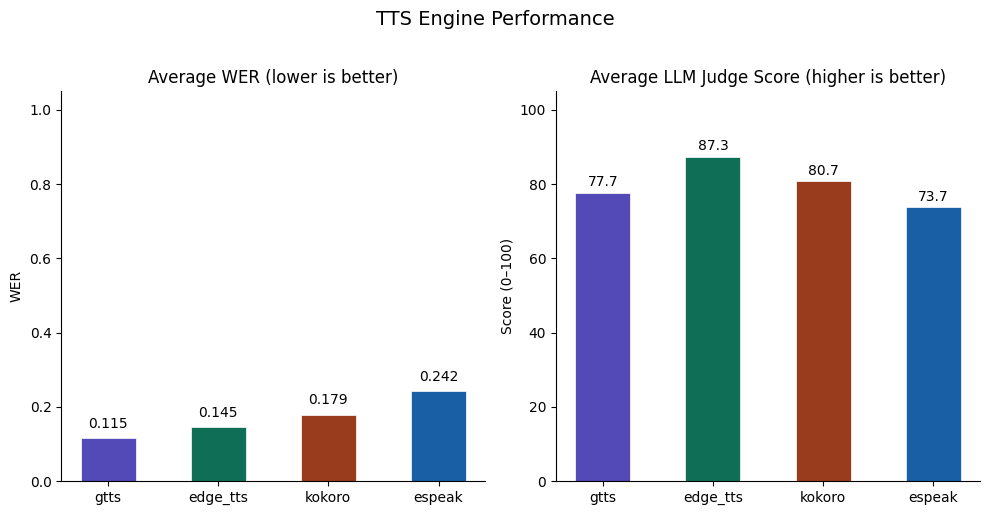

In [ ]:
plot_tts_performance(wer_results, llm_results, question_count=N_QUESTION)

In [ ]:
text = "In our pipeline, game questions and options are provided as audio and first transcribed into text using the best-performing speech-to-text model, Whisper Turbo. The transcribed question can be directly passed to the answering LLM, but noise, filler words, and transcription errors may introduce irrelevant information. To mitigate this, we introduce an intermediate question rewriting step to clean the input and preserve its meaning. However, while this improves input quality, it also increases latency, reducing the time available for answer generation. The evaluation also showed worse performance in the average reached level due to the added complexity in the dialogue, both rewrite and raw question, respect to text game."
audio_byte= synthesize_gtts(text)
Audio(audio_byte)


# Speech To Text evaluation

## Objective: test different Speech to test LLM
- "whisper_turbo",
- "whisper_medium",
- "whisper_base",
- "whisper_small",
- "wav2vec2"

## Auxiliary function

In [ ]:
import json
import re

In [ ]:
def ranking_to_scores(ranking):

    scores = {
        ranking["1"]: 5,
        ranking["2"]: 4,
        ranking["3"]: 3,
        ranking["4"]: 2,
        ranking["5"]: 1,
    }

    return scores

In [ ]:

def extract_json(text):
    text = re.sub(r"```json|```", "", text)
    start = text.find("{")
    end = text.rfind("}") + 1
    return json.loads(text[start:end])

## Prompt Judge

In [ ]:
def build_asr_judge_prompt(candidates):

    system_message = (
        "You are an expert ASR evaluation system.\n"
        "Each system transcribed the SAME question and options.\n\n"

        "Your task:\n"
        "Evaluate how accurately each backend preserved meaning.\n"
        "Score EACH backend from 0 to 100.\n\n"

        "Rules:\n"
        "- 100 = perfect transcription\n"
        "- 0 = completely wrong\n"
        "- consider question + all options\n"
        "- penalize missing words, hallucinations, wrong entities\n\n"

        "Return ONLY valid JSON like:\n"
        "{\n"
        "  \"whisper_turbo\": 92,\n"
        "  \"whisper_base\": 70\n"
        "}\n"
    )

    candidate_text = ""

    for name, data in candidates.items():

        candidate_text += (
            f"\n=== {name} ===\n"
            f"ORIGINAL QUESTION:\n{data['original_question']}\n\n"
            f"ASR QUESTION:\n{data['question_asr']}\n\n"
            f"ORIGINAL OPTIONS:\n" +
            "\n".join(data["original_options"]) +
            "\n\nASR OPTIONS:\n" +
            "\n".join(data["options_asr"]) +
            "\n\n"
        )

    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": candidate_text},
    ]

## Judge

In [ ]:
def judge_asr_outputs(candidates, tokenizer, model):

    messages = build_asr_judge_prompt(candidates)

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    device = next(model.parameters()).device

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
        )

    result = tokenizer.decode(
        outputs[0, inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )

    return extract_json(result)

## Measure accuracy running game

In [ ]:
import os

In [ ]:
def play_game(game, llm_tokenizer, llm_model):
    scores = {b: 0 for b in ASR_BACKENDS}

    while game.in_progress:
        question = game.current_question
        if not question:
            print("No question available.")
            break

        print(f"\n--- Level {game.current_level} ---")
        print(f"Q: {question.text}\n")

        for opt in question.options:
            print(f"  [{opt.id}] {opt.text}")

        time_left = game.time_remaining
        if time_left:
            print(f"\nTime remaining: {time_left:.1f}s")

        candidates = from_text_to_speech_to_text(question)
        scores = judge_asr_outputs(candidates, tokenizer, model)
        print(scores)

        result = game.answer(0)

        if result.correct:
            print("CORRECT!")
            if result.game_over:
                print("\nCONGRATULATIONS!")
                print(f"Final earnings: ${result.earned_amount:,.2f}")
            else:
                print(f"Earned so far: ${result.earned_amount:,.2f}")
        elif result.timed_out:
            print("TIMED OUT!")
            print(f"\nGame Over! Final earnings: ${result.earned_amount:,.2f}")
        else:
            print("WRONG ANSWER!")
            print(f"\nGame Over! Final earnings: ${result.earned_amount:,.2f}")

    print("\n=== Game Summary ===")
    print(f"Reached Level: {game.current_level}")
    print(f"Total Earnings: ${game.earned_amount:,.2f}")
    return game.current_level, scores



## performance

In [ ]:
import numpy as np

global_scores = {}
game_count = 0

In [ ]:
def run_asr_study(n_questions=30):
    global_scores  = {b: 0 for b in ASR_BACKENDS}
    game_count     = 0
    question_count = 0

    while question_count < n_questions:
        print(f"\n=== Starting Game ({question_count}/{n_questions} questions done) ===")

        game = client.game.start(competition_id=comp_id)
        print(f"Session ID: {game.session_id}")
        print(f"Mode: {game.mode}\n")

        reached, scores = play_game(game, tokenizer, model)

        for backend, score in scores.items():
            global_scores[backend] = global_scores.get(backend, 0) + score

        game_count     += 1
        question_count += reached

    # convert totals to averages
    avg_scores = {b: global_scores[b] / max(game_count, 1) for b in global_scores}

    print("\n=== OVERALL ASR ACCURACY ===")
    for backend, avg in avg_scores.items():
        print(f"{backend}: {avg:.2f}")

    return avg_scores

In [ ]:
N_QUESTION=5

In [ ]:
global_scores = run_asr_study(n_questions=N_QUESTION)


=== Starting Game (0/5 questions done) ===
Session ID: 239101
Mode: text


--- Level 1 ---
Q: What event did the IMF warn could hit the UK economy, as reported on 2026-05-18?

  [0] A major earthquake
  [1] A pandemic
  [2] The Iran war
  [3] A global recession

Time remaining: 29.9s



========== WHISPER_TURBO ==========
Question: What event did the IMF warn could hit the UK economy, as reported on 18 May 2026?
Option 0: a major earthquake
Option 1: A pandemic.
Option 2: The Iran War
Option 3: a global recession

========== WHISPER_MEDIUM ==========
Question: What event did the IMF warn could hit the UK economy, as reported on 18 May 2026?
Option 0: A major earthquake.
Option 1: A Pandemic
Option 2: The Iran War
Option 3: A Global Recession

========== WHISPER_BASE ==========
Question: What event did the IMF warn could hit the UK economy as reported on 18 May 2026?
Option 0: A major earthquake.
Option 1: A pandemic.
Option 2: The Iran War
Option 3: A global recession.

========== WHISPER_SMALL ==========
Question: What event did the IMF warn could hit the UK economy as reported on 18 May 2026?
Option 0: A major earthquake.
Option 1: A pandemic
Option 2: The Iran War
Option 3: A global recession.

========== WAV2VEC2 ==========


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Question: WHAT EVENT DID THE I M F WARN COULD HIT THE UKA ECONOMY AS REPORTED ON THE EIGHTEENTH OF MAY TWENTY TWENTY SIXTH
Option 0: A MAJOR EARTHQUAKE
Option 1: A PANDEMIC
Option 2: THE ERON WAR
Option 3: A GLOBAL RECESSION


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


...

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


{'whisper_turbo': 92, 'whisper_medium': 93, 'whisper_base': 85, 'whisper_small': 88, 'wav2vec2': 84}
WRONG ANSWER!

Game Over! Final earnings: $0.00

=== Game Summary ===
Reached Level: 1
Total Earnings: $0.00

=== Starting Game (4/5 questions done) ===
Session ID: 239123
Mode: text


--- Level 1 ---
Q: According to the 2026-05-08 article, where is the developer studio Beethoven and Dinosaur, which created the video game Mixtape, located?

  [0] New York
  [1] Los Angeles
  [2] Melbourne
  [3] Geelong

Time remaining: 29.9s



========== WHISPER_TURBO ==========
Question: according to the the 8th of may 2026 article where is the developer studio beethoven and dinosaur which created the video game mixtape located
Option 0: New York
Option 1: Los Angeles.
Option 2: Melbourne
Option 3: Geelong

========== WHISPER_MEDIUM ==========
Question: According to the 8th of May, 2026 article, where is the developer studio Beethoven and Dinosaur, which created the video game mixtape? Located?
Option 0: New York
Option 1: Los Angeles
Option 2: Melbourne
Option 3: Jalong

========== WHISPER_BASE ==========
Question: According to the 8th of May, 2026 article, where is the developer studio Beethoven and dinosaur? Which created the video game mixtape? Located?
Option 0: New York
Option 1: Los Angeles
Option 2: Melbourne
Option 3: Jellong

========== WHISPER_SMALL ==========
Question: According to the 8th of May 2026 article, where is the developer Studio Beethoven and Dinosaur, which created the video game mixtape? Located?
O

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


{'whisper_turbo': 92, 'whisper_base': 70, 'whisper_medium': 85, 'whisper_small': 83, 'wav2vec2': 80}
WRONG ANSWER!

Game Over! Final earnings: $0.00

=== Game Summary ===
Reached Level: 1
Total Earnings: $0.00

=== OVERALL ASR ACCURACY ===
whisper_turbo: 90.60
whisper_medium: 88.20
whisper_base: 77.80
whisper_small: 86.20
wav2vec2: 84.00


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def plot_asr_performance(avg_scores, game_count, question_count):
    backends = list(avg_scores.keys())
    n        = len(backends)
    colors   = ["#534AB7", "#0F6E56", "#993C1D", "#185FA5", "#854F0B", "#1D9E75", "#D85A30"][:n]

    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, n * 0.8)))
    fig.suptitle("ASR backend performance", fontsize=14, fontweight="bold")

    # Vertical bar
    ax = axes[0]
    bars = ax.bar(range(n), [avg_scores[b] for b in backends],
                  color=colors, width=0.6, edgecolor="white", linewidth=0.5)
    ax.set_title("Avg LLM judge score (higher is better)", fontsize=12)
    ax.set_ylim(0, 115)
    ax.set_ylabel("Score (0–100)")
    ax.set_xticks(range(n))
    ax.set_xticklabels(backends, rotation=35, ha="right", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, b in zip(bars, backends):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{avg_scores[b]:.1f}", ha="center", va="bottom", fontsize=10)

    # Horizontal ranking (sorted)
    ax = axes[1]
    sorted_backends = sorted(backends, key=lambda b: avg_scores[b])
    sorted_colors   = [colors[backends.index(b)] for b in sorted_backends]
    y_pos = np.arange(len(sorted_backends))
    bars  = ax.barh(y_pos, [avg_scores[b] for b in sorted_backends],
                    color=sorted_colors, height=0.6, edgecolor="white", linewidth=0.5)
    ax.set_title("Backend ranking", fontsize=12)
    ax.set_xlim(0, 115)
    ax.set_xlabel("Avg score")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_backends, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    bars[-1].set_edgecolor("#EF9F27")
    bars[-1].set_linewidth(2.5)
    for bar, b in zip(bars, sorted_backends):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{avg_scores[b]:.1f}", va="center", fontsize=10)

    best = sorted_backends[-1]
    summary = (f"Games played: {game_count}   |   "
               f"Questions seen: {question_count}   |   "
               f"Best backend: {best} ({avg_scores[best]:.1f})")
    fig.text(0.5, -0.02, summary, ha="center", fontsize=10, color="gray", style="italic")

    plt.tight_layout()
    plt.show()

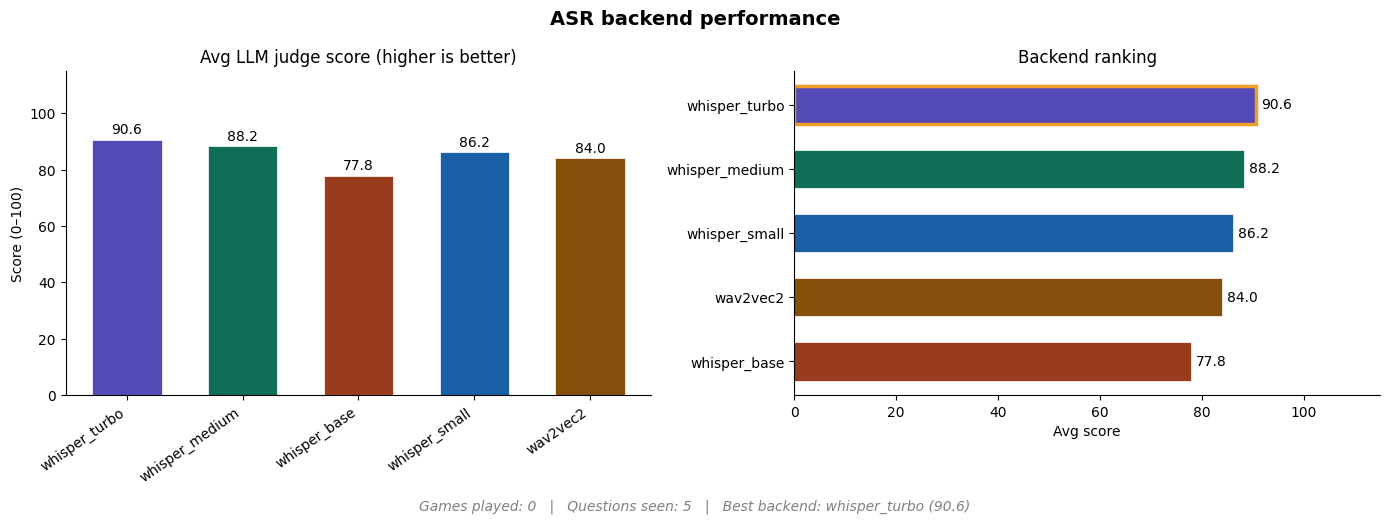

In [ ]:

plot_asr_performance( global_scores, game_count, N_QUESTION)

# Play Speech Game

## LLMs

### General settings

Models we want to try by category:

Small (< 5B parameters):

*   microsoft/Phi-3.5-mini-instruct (thinking)

Medium (5B - 10B parameters):

*   Qwen/Qwen2.5-7B-Instruct


In [ ]:
MODELS_LIST = [
    "microsoft/Phi-3.5-mini-instruct",
    "Qwen/Qwen2.5-7B-Instruct"
]

STRATEGIES_LIST = [
    "zero_shot",
    "one_shot",
    "few_shot",
    "cot",
    "zero_shot_cot"
]

###CONFIG

In [ ]:
import torch

CONFIG = {
    # SELECT HERE THE MODEL TO RUN
    "model_id": "microsoft/Phi-3.5-mini-instruct",

    #quantization
    "quantization_bits": 0, # 4, 8 or None to default 16

    # Select here the strategy to apply
    "prompt_strategy": "zero_shot",
    "n-shots": 2 , # set number of examples to give in the prompt
    "temperature": 1.0,  # sampling temperature (1.0 = default)


    "model_kwargs": {
        "device_map": "auto", # "auto" , "cuda"
        "torch_dtype": "auto",  # "auto", torch.float16, torch.bfloat16, or torch.float32
        "trust_remote_code": True, # Autorizzo Hugging Face
        "attn_implementation": "eager",
    }
}

##LLM loader

###Helper commands


#### Phi helpers

In [1]:
if CONFIG["model_id"].lower().startswith("microsoft/phi-3.5"):
    !pip uninstall -y transformers accelerate
    !pip install transformers==4.43.3 accelerate==0.33.0
    !rm -rf ~/.cache/huggingface/modules

NameError: name 'CONFIG' is not defined

In [ ]:
if CONFIG["model_id"].lower().startswith("microsoft/phi-4"):
    !pip uninstall -y transformers accelerate
    !pip install transformers==4.49.0 accelerate==1.3.0
    !rm -rf ~/.cache/huggingface/modules

####Llama helper

In [ ]:
model_id_lower = CONFIG["model_id"].lower()

if (model_id_lower.startswith("meta-llama/llama-3.2") or model_id_lower.startswith("meta-llama/meta-llama-3")):
    CONFIG["model_kwargs"]["attn_implementation"] = "sdpa"

####Quantization helper

In [ ]:
import torch
import subprocess
import sys

bits = CONFIG.get("quantization_bits")

if bits in {4, 8}:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-U", "transformers", "accelerate", "bitsandbytes"],
        check=True
    )

### Model Loader

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

def load_model(config):
    model_id = config["model_id"]
    kwargs = config["model_kwargs"].copy()

    # attn_implementation controlla come viene calcolata l’attenzione dentro il Transformer.
    if model_id.lower().startswith("microsoft/phi"):
        kwargs["attn_implementation"] = "eager"


    # quantization
    bits = config.get("quantization_bits")

    if bits == 4:
        kwargs["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True)
    elif bits == 8:
        kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)


    display_bits = f"{bits}-bit" if bits else "None (Native/16-bit)"
    print(f"Loading model: {model_id} | Quantization: {display_bits}")

    # 3. Load Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        trust_remote_code=kwargs.get("trust_remote_code", False)
    )

    # 4. Load Model
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        **kwargs
    )

    return tokenizer, model

In [ ]:
# ============================================================
# LOAD MODEL (USING CONFIG)
# ============================================================

llm_tokenizer, llm_model = load_model(CONFIG)

print("Model loaded successfully.")
print("Model name:", CONFIG["model_id"])
print("CUDA available:", torch.cuda.is_available())

try:
    print("Model device:", llm_model.device)
except:
    print("Model device: device_map='auto'")

Loading model: microsoft/Phi-3.5-mini-instruct | Quantization: None (Native/16-bit)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

Model loaded successfully.
Model name: microsoft/Phi-3.5-mini-instruct
CUDA available: True
Model device: cuda:0


## CHATBOT

### Prompting

In [ ]:
# Small DB where examples can be added and then provided for n-shots prompting strategies.

EXAMPLES_DB = {
    "Entertainment": [
        {"q": "Who directed the movie 'Inception'?", "o": "[0] Steven Spielberg\n[1] Christopher Nolan\n[2] Quentin Tarantino\n[3] James Cameron", "a": "1", "r": "'Inception' is a 2010 sci-fi film directed by Christopher Nolan. It is option 1."},
        {"q": "Which band released the album 'Abbey Road'?", "o": "[0] The Rolling Stones\n[1] Led Zeppelin\n[2] The Beatles\n[3] Pink Floyd", "a": "2", "r": "'Abbey Road' is the eleventh studio album by the English rock band The Beatles. It is option 2."},
        {"q": "Which actor played the character of Iron Man in the Marvel Cinematic Universe?", "o": "[0] Chris Evans\n[1] Robert Downey Jr.\n[2] Chris Hemsworth\n[3] Mark Ruffalo", "a": "1", "r": "Robert Downey Jr. portrayed Tony Stark, also known as Iron Man, starting in 2008. It is option 1."}
    ],
    "Ancient History and Politics": [
        {"q": "In which year did the French Revolution begin?", "o": "[0] 1776\n[1] 1789\n[2] 1812\n[3] 1492", "a": "1", "r": "The French Revolution began in 1789 with the Storming of the Bastille. It is option 1."},
        {"q": "Who was the first President of the United States?", "o": "[0] Thomas Jefferson\n[1] Abraham Lincoln\n[2] George Washington\n[3] John Adams", "a": "2", "r": "George Washington served as the first president from 1789 to 1797. It is option 2."},
        {"q": "Which ancient civilization is famous for building the Great Pyramid of Giza?", "o": "[0] The Romans\n[1] The Greeks\n[2] The Egyptians\n[3] The Sumerians", "a": "2", "r": "The Great Pyramid was built as a tomb for the Pharaoh Khufu by the Ancient Egyptians. It is option 2."}
    ],
    "Science and Nature": [
        {"q": "What is the chemical symbol for Gold?", "o": "[0] Gd\n[1] Ag\n[2] Au\n[3] Fe", "a": "2", "r": "The symbol Au comes from the Latin word for gold, 'aurum'. It is option 2."},
        {"q": "Which part of the cell is known as the powerhouse?", "o": "[0] Nucleus\n[1] Ribosome\n[2] Mitochondria\n[3] Golgi apparatus", "a": "2", "r": "Mitochondria generate most of the cell's supply of adenosine triphosphate (ATP). It is option 2."},
        {"q": "What is the closest planet to the Sun?", "o": "[0] Venus\n[1] Mars\n[2] Mercury\n[3] Earth", "a": "2", "r": "Mercury is the smallest and innermost planet in the Solar System. It is option 2."}
    ],
    "Maths": [
        {"q": "What is the square root of 144?", "o": "[0] 10\n[1] 11\n[2] 12\n[3] 14", "a": "2", "r": "12 multiplied by 12 equals 144. It is option 2."},
        {"q": "Solve for x: 2x + 5 = 15", "o": "[0] 5\n[1] 10\n[2] 15\n[3] 20", "a": "0", "r": "Subtract 5 from 15 to get 10, then divide by 2. x = 5. It is option 0."},
        {"q": "What is the value of 5 factorial (5!)?", "o": "[0] 60\n[1] 100\n[2] 120\n[3] 150", "a": "2", "r": "The factorial of 5 is 5 * 4 * 3 * 2 * 1, which equals 120. It is option 2."}
    ],
    "Philosophy and Psychology": [
        {
            "q": "Who is known for the theory of the 'social contract'?",
            "o": "[0] Plato\n[1] Jean-Jacques Rousseau\n[2] Friedrich Nietzsche\n[3] Karl Marx",
            "a": "1",
            "r": "Jean-Jacques Rousseau is one of the most famous philosophers associated with social contract theory. It is option 1."
        },
        {
            "q": "Which psychologist developed the hierarchy of needs?",
            "o": "[0] Sigmund Freud\n[1] B.F. Skinner\n[2] Abraham Maslow\n[3] Carl Jung",
            "a": "2",
            "r": "Abraham Maslow introduced the hierarchy of needs theory in motivational psychology. It is option 2."
        },
        {
            "q": "What does the term 'cognitive dissonance' describe?",
            "o": "[0] A state of mental relaxation\n[1] Conflicting beliefs causing psychological discomfort\n[2] Loss of memory over time\n[3] A personality disorder",
            "a": "1",
            "r": "Cognitive dissonance refers to the discomfort experienced when holding conflicting beliefs or attitudes. It is option 1."
        }
    ],

    "News": [
        {
            "q": "Which organization is responsible for maintaining international peace and security?",
            "o": "[0] NATO\n[1] United Nations\n[2] European Union\n[3] World Bank",
            "a": "1",
            "r": "The United Nations was founded to promote international cooperation and maintain peace. It is option 1."
        },
        {
            "q": "What does GDP stand for in economics?",
            "o": "[0] General Development Plan\n[1] Gross Domestic Product\n[2] Global Distribution Percentage\n[3] Government Debt Policy",
            "a": "1",
            "r": "GDP stands for Gross Domestic Product, a measure of economic output. It is option 1."
        },
        {
            "q": "Which technology is primarily associated with cryptocurrencies like Bitcoin?",
            "o": "[0] Blockchain\n[1] Cloud Computing\n[2] Virtual Reality\n[3] Quantum Processing",
            "a": "0",
            "r": "Blockchain is the decentralized ledger technology used by cryptocurrencies. It is option 0."
        }
    ]
}

In [ ]:
import random
def get_examples(n=1):
    category_list = EXAMPLES_DB.get(chosen_comp)
    # Return n samples, or the whole list if n is larger than available questions
    return random.sample(category_list, min(n, len(category_list)))

In [ ]:
def format_options(options):
    return "\n".join([f"[{opt.id}] {opt.text}" for opt in options])

In [ ]:
# Prompt builders

def build_zero_shot_prompt(question_text, options):
    options_text = format_options(options)

    system_message = (
        "You are playing a multiple-choice quiz game.\n"
        f"You are an expert of {chosen_comp}.\n"
        "Choose the correct answer for the question delimited by triple backticks.\n\n"
        "Rules:\n"
        "- Return only the option ID.\n"
        "- Do not explain.\n"
        "- Do not write anything except one number."
    )

    user_message = (
        f"```{question_text}```\n\n"
        f"Options:\n{options_text}\n\n"
        "Answer:"
    )
    return system_message, user_message

def build_one_shot_prompt(question_text, options):
    options_text = format_options(options)
    # return only 1 example
    ex = get_examples(1)[0]

    system_message = (
        "You are playing a multiple-choice quiz game.\n"
        f"You are an expert of {chosen_comp}.\n"
        "Choose the correct answer for the question delimited by triple backticks.\n\n"
        "Rules:\n"
        "- Return only the option ID.\n"
        "- Do not explain.\n"
        "- Do not write anything except one number.\n\n"
        "Example :\n\n"
        f"```{ex['q']}```\n\n"
        f"Options:\n{ex['o']}\n\n"
        f"Answer: {ex['a']}"
    )

    user_message = (
        f"```{question_text}```\n\n"
        f"Options:\n{options_text}\n\n"
        "Answer:"
    )

    return system_message, user_message


def build_few_shot_prompt(question_text, options):
    options_text = format_options(options)
    n_shots = CONFIG["n-shots"]
    examples = get_examples(n_shots)

    example_blocks = []
    for ex in examples:
        block = f"```{ex['q']}```\nOptions:\n{ex['o']}\nAnswer: {ex['a']}"
        example_blocks.append(block)

    system_message = (
        "You are playing a multiple-choice quiz game.\n"
        f"You are an expert of {chosen_comp}.\n"
        "Choose the correct answer for the question delimited by triple backticks.\n\n"
        "Rules:\n"
        "- Return only the option ID.\n"
        "- Do not explain.\n"
        "- Do not write anything except one number.\n\n"
        "Examples:\n\n" + "\n\n".join(example_blocks)
    )

    user_message = (
        f"```{question_text}```\n\n"
        f"Options:\n{options_text}\n\n"
        "Answer:"
    )

    return system_message, user_message


def build_cot_prompt(question_text, options):
    options_text = format_options(options)
    n_shots = CONFIG["n-shots"]
    examples = get_examples(n_shots)

    example_blocks = []
    for ex in examples:
        block = (
            f"```{ex['q']}```\n"
            f"Options:\n{ex['o']}\n"
            f"Reasoning: {ex['r']}\n"
            f"Answer: {ex['a']}"
        )
        example_blocks.append(block)

    system_message = (
        "You are playing a multiple-choice quiz game.\n"
        f"You are an expert of {chosen_comp}.\n"
        "To answer the question delimited by triple backticks, follow these steps:\n"
        "Step 1 - Read the question carefully.\n"
        "Step 2 - Consider each option and reason about it.\n"
        "Step 3 - Select the most plausible answer.\n"
        "Step 4 - Output your answer using this format:\n"
        "Reasoning: <your reasoning>\n"
        "Answer: <option ID>\n\n"
        "Examples:\n\n" + "\n\n".join(example_blocks)
    )

    user_message = (
        f"```{question_text}```\n\n"
        f"Options:\n{options_text}\n\n"
        "Reasoning:"
    )

    return system_message, user_message


def build_zero_shot_cot_prompt(question_text, options):
    options_text = format_options(options)

    system_message = (
        "You are playing a multiple-choice quiz game.\n"
        f"You are an expert of {chosen_comp}.\n"
        "Analyze the question delimited by triple backticks and choose the correct answer.\n\n"
        "Follow these steps:\n"
        "Step 1 - Reason step by step about the question and each option.\n"
        "Step 2 - If the question is ambiguous, choose the most plausible answer.\n"
        "Step 3 - Output your answer as a JSON object with these keys:\n"
        "  - \"reasoning\": your step-by-step reasoning as a string\n"
        "  - \"answer\": the option ID as an integer\n\n"
        "Output only valid JSON. Do not add any text outside the JSON object."
    )

    user_message = (
        f"```{question_text}```\n\n"
        f"Options:\n{options_text}"
    )

    return system_message, user_message

In [ ]:
PROMPT_BUILDERS = {
    "zero_shot": build_zero_shot_prompt,
    "one_shot": build_one_shot_prompt,
    "few_shot": build_few_shot_prompt,
    "cot": build_cot_prompt,
    "zero_shot_cot": build_zero_shot_cot_prompt,
}

def build_prompt(question_text, options):
    prompt_strategy = CONFIG["prompt_strategy"]

    if prompt_strategy not in PROMPT_BUILDERS:
        #Default to zero-shot prompt strategy
        prompt_strategy = "zero_shot"

    if prompt_strategy in {"few_shot", "cot"}:
        print(f"Using {prompt_strategy} prompting strategy with {CONFIG["n-shots"]} examples")
        return PROMPT_BUILDERS[prompt_strategy](question_text, options)

    print(f"Using {prompt_strategy} prompting strategy")
    return PROMPT_BUILDERS[prompt_strategy](question_text, options)


####Dynamic prompting

In [ ]:
# Dynamic prompting configuration

DYNAMIC_PROMPTING = {
    "enabled": False,

    # Prompt used from level 1 up to "switch_after_level"
    "first_prompt_strategy": "zero_shot",

    # Last level in which the first prompt is used
    "switch_after_level": 7,

    # Prompt used from the next level onward
    "second_prompt_strategy": "cot",
}


def get_prompt_strategy_for_level(current_level):
    if not DYNAMIC_PROMPTING["enabled"]:
        return CONFIG["prompt_strategy"]

    if current_level <= DYNAMIC_PROMPTING["switch_after_level"]:
        return DYNAMIC_PROMPTING["first_prompt_strategy"]

    return DYNAMIC_PROMPTING["second_prompt_strategy"]

### Extraction options

For different Prompting Strategies


In [ ]:
import json

def extract_option_id_json(output, valid_ids):
    try:
        match = re.search(r'\{.*\}', output, re.DOTALL)
        if match:
            data = json.loads(match.group())
            ans = int(data.get("answer"))
            if ans in valid_ids:
                return ans
    except:
        pass
    return None

def extract_option_id_cot(output, valid_ids):
    match = re.search(r'(?:Answer|Answer is)[\s:]*([0-9]+)', output, re.IGNORECASE)
    if match:
        ans = int(match.group(1))
        if ans in valid_ids:
            return ans
    numbers = re.findall(r'\b\d+\b', output)
    if numbers:
        ans = int(numbers[-1])
        if ans in valid_ids:
            return ans
    return None

def extract_option_id(output, valid_ids):
    match = re.search(r'(?:Answer|Answer is)[\s:]*([0-9]+)', output, re.IGNORECASE)
    if match:
        ans = int(match.group(1))
        if ans in valid_ids:
            return ans
    numbers = re.findall(r'\b\d+\b', output)
    if numbers:
        ans = int(numbers[0])
        if ans in valid_ids:
            return ans
    return None

### Answer preparation

In [ ]:
import re
def generate_answer(prompt, tokenizer, model, do_sample=True, max_new_tokens=15, temperature=1.0):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[-1]
    #prompt_len = len(prompt)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature,
            #use_cache=False
        )

    # We cut-off the "raw part" and return only the reasoning +
    # Answer: []

    pruned_output = tokenizer.decode(
        outputs[0][prompt_len:],
        skip_special_tokens=True
    ).strip()

    return pruned_output


def parse_answer(output, valid_ids):

    prompt_strategy = CONFIG["prompt_strategy"]

    if prompt_strategy == "zero_shot_cot":
        return extract_option_id_json(output, valid_ids)

    if prompt_strategy == "cot":
        return extract_option_id_cot(output, valid_ids)

    return extract_option_id(output, valid_ids)

def get_llm_answer(question, tokenizer, model, max_retries=3):

    valid_ids = [opt.id for opt in question.options]
    system_msg, user_msg = build_prompt(question.text , question.options)

    #For Debug
    #print(f"System message:\n {system_msg}")

    # Applica il Chat Template
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg}
    ]

    # TODO: capire se potrebbe avere problemi con alcuni modelli
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    max_new_tokens = CONFIG.get("max_new_tokens", 15)

    # Assign higher number of tokens if reasoning is required
    if CONFIG["prompt_strategy"] in {"zero_shot_cot", "cot"}:
        max_new_tokens = CONFIG.get("reasoning_max_new_tokens", 256)


    # retry if the llm fails 3 times
    for _ in range(max_retries):

        output = generate_answer(prompt, tokenizer, model, do_sample=CONFIG.get("do_sample",True), max_new_tokens=max_new_tokens, temperature=CONFIG.get("temperature", 1.0))

        print(f"Output: (Reasoning, if selected, + Answer):\n {output}")
        answer = parse_answer(output, valid_ids)

        #print(f"\nLA RISPOSTA QUA è: {answer}")
        if answer is not None:
            return answer

    # fallback to
    print("\nFallback...")
    return valid_ids[0]

## Rewrite question text transcripted by Whisper

### Rewrite question's option

In [ ]:
def build_few_shot_prompt_rewrite_option(option_text):
    system_message = (
        "You are a text denoiser. Remove only ASR noise: filler words (uh, um, haha), "
        "stutters, and gibberish sounds. Return ONLY the cleaned text as a single short phrase. "
        "Do NOT answer. Do NOT explain. Do NOT add ANY content. Do NOT reference previous questions. "
        "If already clean, return it exactly as-is.\n\n"
        "Examples:\n"
        "INPUT: 'fermentation ah oh ahahsahssh eh ?' → OUTPUT: 'fermentation'\n"
        "INPUT: 'option C. option c Topshin D. ro uh mantic comedy' → OUTPUT: 'romantic comedy'\n"
        "INPUT: '! Film Noir!' → OUTPUT: 'Film Noir'\n"
        "INPUT: 'the Menoir' → OUTPUT: 'the Menoir'\n"
        "Now clean this text and return ONLY the result, nothing else:"
    )

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": option_text},
    ]
    return messages

In [ ]:
def rewrite_option(option_text, tokenizer, model, max_new_tokens=40):
    messages = build_few_shot_prompt_rewrite_option(option_text)

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    cleaned = tokenizer.decode(
        outputs[0, inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True,
    ).strip()

    # take only first line in case model generates extra text
    cleaned = cleaned.split("\n")[0].strip()

    return cleaned if cleaned else option_text


### Rewrite all question's options

In [ ]:

def rewrite_options(question, tokenizer, model):
    for i, opt in enumerate(question.options):
        original = opt.text if hasattr(opt, "text") else str(opt)
        cleaned = rewrite_option(original, tokenizer, model)
        if cleaned:  # only update if non-empty
            if hasattr(opt, "text"):
                opt.text = cleaned
            else:
                question.options[i] = cleaned
    return question

### Rewrite question's text

In [ ]:
def build_few_shot_prompt_rewrite_question_text(question_text):

    system_message = (
        "You are a text denoiser. Remove only ASR noise: filler words "
        "(uh, um, haha), stutters, repeated words, and gibberish sounds. "
        "Preserve the original meaning and question structure exactly. "
        "Return ONLY the cleaned question text. "
        "Do NOT answer. Do NOT explain. Do NOT add ANY content. "
        "Remove answer options such as A), B), C), D) and remove explanatory notes. "
        "If already clean, return it exactly as-is except for option/note removal.\n\n"

        "Examples:\n"

        "INPUT: 'Uh, how does, haha, Pink Floyd use, um, absence as a theme in Wish You Were Here?'\n"
        "OUTPUT: 'How does Pink Floyd use absence as a theme in Wish You Were Here?'\n\n"

        "INPUT: 'What, uh, term describes a song specially created for an anime series?'\n"
        "OUTPUT: 'What term describes a song specially created for an anime series?'\n\n"

        "Now clean this text and return ONLY the result, nothing else:"
    )

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": question_text},
    ]

    return messages

In [ ]:
def rewrite_question_text(question, tokenizer, model):

    original_text = question.text

    messages = build_few_shot_prompt_rewrite_question_text(question.text)

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    device = next(model.parameters()).device
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

    input_len = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=min(256, input_len),
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    cleaned = tokenizer.decode(
        outputs[0, input_len:],
        skip_special_tokens=True
    ).strip()

    cleaned = cleaned.split("\n")[0].strip()

    question.text = cleaned if cleaned else original_text

    return question

## Question class



In [ ]:
import re

def remove_option_prefix(text):
    return re.sub(r"Option\s+[A-D][,.]?\s*", "", text)

In [ ]:
# Simple container to mimic question.options structure
class TranscribedOption:
    def __init__(self, id, text):
        self.id = id
        self.text = remove_option_prefix(text)

class TranscribedQuestion:
    def __init__(self, text, options):
        self.text = text
        self.options = options  # list of TranscribedOption



## Transcription of question class

In [ ]:

def transcribe_game_audio(question_audio: bytes, option_audios: list[bytes]) -> TranscribedQuestion:
    print("Transcribing question...")
    question_text = transcribe_audio_bytes(question_audio)
    print(f"  Q: {question_text}")

    options = []
    for i, audio in enumerate(option_audios):
        letter = chr(65 + i)  # A, B, C, D
        print(f"Transcribing option {letter}...")
        option_text = transcribe_audio_bytes(audio)
        print(f"  {letter}: {option_text}")
        options.append(TranscribedOption(id=i, text=option_text))

    return TranscribedQuestion(text=question_text, options=options)



## Print question

In [ ]:
def print_question(question):
  print("\n QUESTION: ", question.text, "\n")
  for opt in question.options:
    print(opt.id, ": ", opt.text)
  print("\n")


## Game

In [ ]:
import os

In [ ]:
def play_game(game, tokenizer, model):
    os.makedirs("Audio", exist_ok=True)
    while game.in_progress:
        print(f"\n--- Level {game.current_level} ---")

        # Fetch question audio
        print("Fetching question audio...")
        try:
            question_audio = game.fetch_audio_question()
            file_path_question=f"Audio/level_{game.current_level}_question.wav"
            save_audio(question_audio, file_path_question)
            display(Audio(question_audio))
        except GameError as e:
            print(f"Error fetching question audio: {e}")
            break

        # Fetch option audios sequentially (A, B, C, D)
        option_map = {}
        audios = []
        for i in range(4):
            letter = chr(65 + i)  # A, B, C, D
            print(f"Fetching option {letter} audio...")
            try:
                option_audio = game.fetch_audio_option_next()
                file_path_options=f"level_{game.current_level}_option_{letter}.wav"
                save_audio(option_audio, file_path_options)
                audios.append(option_audio)
            except GameError as e:
                print(f"Error fetching option audio: {e}")
                break

            # Store mapping for answer submission
            if game.current_question and i < len(game.current_question.options):
                option_map[letter] = game.current_question.options[i].id

        display(Audio(audios[0]),
                Audio(audios[1]),
                Audio(audios[2]),
                Audio(audios[3])) # Pardon this horrific hard-coded stuff, due to (even more horrific) ipykernel logic. ~Federico

        if not option_map:
            print("No question available. Game may have ended.")
            break

        game.refresh_state()

        # Get time remaining (timer starts after Option D is fetched)
        time_left = game.time_remaining
        if time_left is not None:
            print(f"\nTime remaining: {time_left:.1f}s")


        transcribed_question = transcribe_game_audio(question_audio, audios)

        print_question(transcribed_question)

        question = rewrite_question_text(transcribed_question, tokenizer, model)

        print("title changed")

        question = rewrite_options(question, tokenizer, model)

        print_question(question)

        # Get answer
        answer_id = get_llm_answer(question, tokenizer, model)
        print("Answer LLM: ", answer_id)
        '''
        answer_input = input("\nYour answer (A/B/C/D): ").strip().upper()
        if answer_input not in option_map:
            print("Invalid input. Please enter A, B, C, or D.")
            continue
        '''
        #answer_id = option_map[answer_id]
        result = game.answer(answer_id)

        # Handle timeout
        if result.timed_out or result.status == "timeout":
            print(" TIME'S UP!")
            print(f"\n Game Over! You ran out of time.")
            print(f" Final earnings: ${result.earned_amount:,.2f}")
            break

        if result.correct:
            print(" CORRECT!")
            if result.game_over:
                print(f"\n CONGRATULATIONS! You completed the game!")
                print(f" Final earnings: ${result.earned_amount:,.2f}")
            else:
                print(f" Earned so far: ${result.earned_amount:,.2f}")
        else:
            print(" WRONG!")
            print(f"\n Game Over!")
            print(f" Final earnings: ${result.earned_amount:,.2f}")
    print("\n=== Game Summary ===")
    print(f"Reached Level: {game.current_level}")
    print(f"Total Earnings: ${game.earned_amount:,.2f}")
    return game.current_level

In [ ]:
# Start speech mode game
'''
reached=0;
count=0;
reachedlevel = [0] * 17
while(reached<15):
  print("\n=== Starting Game (With mode selection)===")
  game = client.game.start(competition_id=comp_id, mode="speech")
  print(f"Session ID: {game.session_id}")
  print(f"Mode: {game.mode}")
  print()
  reached= play_game(game, llm_tokenizer, llm_model)
  reachedlevel[reached]+=1
  count+=1
print("DONE REACHED 15 at ", count)
print(reachedlevel)
'''

game = client.game.start(competition_id=comp_id, mode="speech")
print(f"Session ID: {game.session_id}")
print(f"Mode: {game.mode}")


Session ID: 256517
Mode: speech


In speech mode, the 30 seconds timer is starting when we are requesting the last option!!

In [ ]:
# Show leaderboard position (speech mode)
lb = client.leaderboard.get(competition_id=comp_id, limit=10, mode="speech")
print(f"\n=== Speech Leaderboard for {lb.competition.name} ===")
for i, entry in enumerate(lb.entries[:10], 1):
    marker = " <-- YOU" if entry.username == username else ""
    print(f"  {i}. {entry.username}: ${entry.score:,.2f} (Level {entry.reached_level}){marker}")


=== Speech Leaderboard for News ===
  1. El_Marzel: $1,024,000.00 (Level 15)
  2. leonfuss: $128,000.00 (Level 12)
  3. grepapetti: $64,000.00 (Level 11)
  4. gioferola: $32,000.00 (Level 10)
  5. luca_bordin: $16,000.00 (Level 9)
  6. SYNC: $2,000.00 (Level 6)
  7. gvin: $500.00 (Level 4)
  8. IWillBeABillionaire: $500.00 (Level 4)
  9. MTKY: $500.00 (Level 4)
  10. Vercingetorige: $500.00 (Level 4) <-- YOU


## Performance

### Collect data on json

In [ ]:
# ============================================================
# SPEECH-TO-TEXT LLM BENCHMARK LOGGER - STRUCTURED VERSION
# Tests:
#   - speech mode game
#   - Whisper transcription
#   - optional LLM rewrite/denoising
#   - LLM answer
#
# Saves both:
#   1. Global append-only files for analysis
#   2. Structured folders for manual inspection
#
# Requires already defined:
#   - CONFIG
#   - client
#   - llm_tokenizer
#   - llm_model
#   - whisper_model
#   - transcribe_audio_bytes(...)
#   - rewrite_question_text(...)
#   - rewrite_options(...)
#   - build_prompt(...)
#   - generate_answer(...)
#   - parse_answer(...)
#   - get_prompt_strategy_for_level(...)
# ============================================================

import os
import re
import json
import time
import uuid
import hashlib
import traceback
from copy import deepcopy
from pathlib import Path
from datetime import datetime

import pandas as pd


# ============================================================
# Speech benchmark settings
# ============================================================

SPEECH_BENCHMARK_LOG_DIR = "/content/gdrive/MyDrive/NLP/PoliMillionaire/logs_speech"

SPEECH_PROMPT_STRATEGIES_TO_TEST = [
    "few_shot",
    # "zero_shot",
    # "cot",
]

SPEECH_COMPETITIONS_TO_TEST = {
    #0: "Entertainment",
    1: "Ancient History and Politics",
    #2: "Science and Nature",
    #3: "Maths",
    #4: "Philosophy and Psychology",
    5: "News",
}

# Start with 1 to verify everything works.
# Later increase to 3 or more.
SPEECH_N_RUNS_PER_CONFIG = 15

SPEECH_N_SHOTS_BY_PROMPT = {
    "zero_shot": 0,
    "few_shot": 1
}

# Two useful variants:
# - raw: Whisper transcription goes directly to the LLM
# - rewrite: Whisper transcription is cleaned by the LLM before answering
SPEECH_VARIANTS_TO_TEST = [
    {
        "speech_variant_name": "stt_raw_llm",
        "rewrite_question": False,
        "rewrite_options": False,
    },
    {
        "speech_variant_name": "stt_rewrite_llm",
        "rewrite_question": True,
        "rewrite_options": True,
    },
]

# Put the actual Whisper model name you loaded above.
# Example: "base", "small", "turbo"
SPEECH_STT_MODEL_NAME = "turbo"

SAVE_FULL_SPEECH_PROMPT = False
SAVE_AUDIO_FILES = True


# ============================================================
# Speech global paths
# ============================================================

SPEECH_LOG_ROOT = Path(SPEECH_BENCHMARK_LOG_DIR)
SPEECH_LOG_ROOT.mkdir(parents=True, exist_ok=True)

SPEECH_GLOBAL_RUNS_INDEX_PATH = SPEECH_LOG_ROOT / "all_speech_runs_index.jsonl"
SPEECH_GLOBAL_QUESTIONS_INDEX_PATH = SPEECH_LOG_ROOT / "all_speech_questions_index.jsonl"
SPEECH_GLOBAL_CRASHED_RUNS_PATH = SPEECH_LOG_ROOT / "crashed_speech_runs.jsonl"
SPEECH_LATEST_CHECKPOINT_PATH = SPEECH_LOG_ROOT / "latest_speech_checkpoint.json"


# ============================================================
# Utility functions
# ============================================================

def speech_make_json_serializable(obj):
    if isinstance(obj, dict):
        return {str(k): speech_make_json_serializable(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [speech_make_json_serializable(v) for v in obj]

    if isinstance(obj, tuple):
        return [speech_make_json_serializable(v) for v in obj]

    if isinstance(obj, Path):
        return str(obj)

    try:
        json.dumps(obj)
        return obj
    except TypeError:
        return str(obj)


def speech_save_json(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(speech_make_json_serializable(data), f, ensure_ascii=False, indent=2)


def speech_append_jsonl(path, record):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(speech_make_json_serializable(record), ensure_ascii=False) + "\n")


def speech_load_jsonl(path):
    path = Path(path)

    if not path.exists():
        return []

    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))

    return rows


def speech_safe_name(value):
    value = str(value)
    value = value.replace("/", "__")
    value = value.replace(" ", "_")
    value = re.sub(r"[^a-zA-Z0-9_\-=.]", "", value)
    return value


def speech_parse_money(value):
    try:
        return float(value)
    except Exception:
        return value


def speech_safe_getattr(obj, attr_name, default=None):
    return getattr(obj, attr_name, default)


def speech_get_model_short_name(model_id):
    if model_id is None:
        return "unknown_model"
    return str(model_id).split("/")[-1]


def speech_get_option_dict(question):
    return {opt.id: opt.text for opt in question.options}


def speech_get_valid_option_ids(question):
    return [opt.id for opt in question.options]


def speech_save_audio(data: bytes, filename: str):
    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)

    with open(filename, "wb") as f:
        f.write(data)

    return str(filename)


def speech_remove_option_prefix(text):
    return re.sub(r"^\s*(Option\s+)?[A-D][\.\),:]?\s*", "", str(text)).strip()


class SpeechTranscribedOption:
    def __init__(self, option_id, text):
        self.id = option_id
        self.text = speech_remove_option_prefix(text)


class SpeechTranscribedQuestion:
    def __init__(self, text, options):
        self.text = text
        self.options = options


# ============================================================
# Config hash and folder builder
# ============================================================

def get_speech_config_hash(model_config, prompt_strategy, competition_id, speech_variant):
    relevant_config = {
        "technique_name": "speech_to_text_llm",
        "mode": "speech",
        "model_config": speech_make_json_serializable(model_config),
        "prompt_strategy": prompt_strategy,
        "competition_id": competition_id,
        "stt_model_name": SPEECH_STT_MODEL_NAME,
        "speech_variant": speech_make_json_serializable(speech_variant),
    }

    config_string = json.dumps(relevant_config, sort_keys=True)
    return hashlib.md5(config_string.encode("utf-8")).hexdigest()[:10]


def build_speech_run_folder(log_root, run_metadata):
    model_config = run_metadata["model_config"]

    model_id = model_config.get("model_id", "unknown_model")
    model_name = speech_get_model_short_name(model_id)

    quant = model_config.get("quantization_bits", "none")
    prompt = run_metadata.get("benchmark_prompt_strategy", "unknown_prompt")

    comp_id = run_metadata.get("competition_id", "unknown")
    comp_name = run_metadata.get("competition_name", "unknown_category")
    category = f"{comp_id}_{comp_name}"

    variant_name = run_metadata.get("speech_variant_name", "unknown_speech_variant")
    stt_model = run_metadata.get("stt_model_name", "unknown_stt")

    folder = (
        Path(log_root)
        / "speech_to_text_llm"
        / f"variant={speech_safe_name(variant_name)}"
        / f"stt={speech_safe_name(stt_model)}"
        / f"model={speech_safe_name(model_name)}"
        / f"quant={speech_safe_name(quant)}"
        / f"prompt={speech_safe_name(prompt)}"
        / f"category={speech_safe_name(category)}"
    )

    folder.mkdir(parents=True, exist_ok=True)
    (folder / "full_runs").mkdir(parents=True, exist_ok=True)
    (folder / "audio").mkdir(parents=True, exist_ok=True)

    return folder


# ============================================================
# Logged LLM answer function
# ============================================================

def get_llm_answer_logged_for_speech(question, tokenizer, model, max_retries=3):
    """
    Same idea as get_llm_answer, but returns logging metadata.
    This function receives the transcribed/cleaned question.
    """

    valid_ids = speech_get_valid_option_ids(question)

    system_msg, user_msg = build_prompt(question.text, question.options)

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    max_new_tokens = CONFIG.get("max_new_tokens", 15)

    if CONFIG.get("prompt_strategy") in {"zero_shot_cot", "cot"}:
        max_new_tokens = CONFIG.get("reasoning_max_new_tokens", 256)

    attempts = []

    for attempt_idx in range(1, max_retries + 1):

        output = generate_answer(
            prompt,
            tokenizer,
            model,
            do_sample=CONFIG.get("do_sample", True),
            max_new_tokens=max_new_tokens,
            temperature=CONFIG.get("temperature", 1.0),
        )

        parsed_answer = parse_answer(output, valid_ids)

        attempts.append({
            "attempt": attempt_idx,
            "raw_output": output,
            "parsed_answer": parsed_answer,
        })

        print(f"Output: (Reasoning, if selected, + Answer):\n{output}")

        if parsed_answer is not None:
            return {
                "answer_id": parsed_answer,
                "raw_output": output,
                "parsed_answer": parsed_answer,
                "used_fallback": False,
                "attempts": attempts,
                "prompt": prompt if SAVE_FULL_SPEECH_PROMPT else None,
                "max_new_tokens": max_new_tokens,
            }

    fallback_answer = valid_ids[0]

    print("\nFallback answer used.")

    return {
        "answer_id": fallback_answer,
        "raw_output": attempts[-1]["raw_output"] if attempts else None,
        "parsed_answer": fallback_answer,
        "used_fallback": True,
        "attempts": attempts,
        "prompt": prompt if SAVE_FULL_SPEECH_PROMPT else None,
        "max_new_tokens": max_new_tokens,
    }


# ============================================================
# Audio fetch + transcription
# ============================================================

def fetch_and_transcribe_speech_question(game, run_folder, run_id, level):
    """
    Fetches question audio and 4 option audios from the speech game,
    saves audio files if enabled, and transcribes them with Whisper.
    """

    audio_folder = Path(run_folder) / "audio" / run_id / f"level_{level}"
    audio_folder.mkdir(parents=True, exist_ok=True)

    fetch_start = time.time()

    print("Fetching question audio...")
    question_audio = game.fetch_audio_question()

    question_audio_path = None
    if SAVE_AUDIO_FILES:
        question_audio_path = speech_save_audio(
            question_audio,
            audio_folder / "question.wav"
        )

    option_audios = []
    option_audio_paths = []

    for i in range(4):
        letter = chr(65 + i)
        print(f"Fetching option {letter} audio...")

        option_audio = game.fetch_audio_option_next()
        option_audios.append(option_audio)

        if SAVE_AUDIO_FILES:
            option_audio_path = speech_save_audio(
                option_audio,
                audio_folder / f"option_{letter}.wav"
            )
        else:
            option_audio_path = None

        option_audio_paths.append(option_audio_path)

    fetch_audio_time_sec = time.time() - fetch_start

    # In speech mode, according to your notebook, the timer starts after option D.
    game.refresh_state()
    time_remaining_after_audio_fetch = game.time_remaining

    print(f"\nAudio fetch time: {fetch_audio_time_sec:.2f}s")

    if time_remaining_after_audio_fetch is not None:
        print(f"Time remaining after audio fetch: {time_remaining_after_audio_fetch:.1f}s")

    stt_start = time.time()

    print("\nTranscribing question...")
    question_stt_start = time.time()
    raw_question_text = transcribe_audio_bytes(question_audio)
    question_stt_time_sec = time.time() - question_stt_start
    print("Q:", raw_question_text)

    raw_option_texts = {}
    option_stt_times = {}

    option_ids = [0, 1, 2, 3]

    # If the server exposes current_question with original option ids, keep them.
    if game.current_question is not None and hasattr(game.current_question, "options"):
        try:
            option_ids = [opt.id for opt in game.current_question.options]
        except Exception:
            option_ids = [0, 1, 2, 3]

    transcribed_options = []

    for i, option_audio in enumerate(option_audios):
        letter = chr(65 + i)
        option_id = option_ids[i] if i < len(option_ids) else i

        print(f"Transcribing option {letter}...")

        opt_start = time.time()
        option_text = transcribe_audio_bytes(option_audio)
        opt_elapsed = time.time() - opt_start

        raw_option_texts[str(option_id)] = option_text
        option_stt_times[str(option_id)] = opt_elapsed

        print(f"{letter} / id={option_id}: {option_text}")

        transcribed_options.append(
            SpeechTranscribedOption(
                option_id=option_id,
                text=option_text,
            )
        )

    total_stt_time_sec = time.time() - stt_start

    transcribed_question = SpeechTranscribedQuestion(
        text=raw_question_text,
        options=transcribed_options,
    )

    return {
        "question": transcribed_question,

        "raw_question_text": raw_question_text,
        "raw_option_texts": raw_option_texts,

        "question_audio_path": question_audio_path,
        "option_audio_paths": option_audio_paths,

        "fetch_audio_time_sec": fetch_audio_time_sec,
        "time_remaining_after_audio_fetch": time_remaining_after_audio_fetch,

        "question_stt_time_sec": question_stt_time_sec,
        "option_stt_times": option_stt_times,
        "total_stt_time_sec": total_stt_time_sec,
    }


# ============================================================
# Optional rewrite / denoising
# ============================================================

def maybe_rewrite_speech_question(question, tokenizer, model, speech_variant):
    """
    Optionally cleans the transcribed question and options using the LLM.
    """

    rewrite_question_enabled = speech_variant.get("rewrite_question", False)
    rewrite_options_enabled = speech_variant.get("rewrite_options", False)

    before_question_text = question.text
    before_options = speech_get_option_dict(question)

    rewrite_start = time.time()

    if rewrite_question_enabled:
        print("\nRewriting question text...")
        question = rewrite_question_text(question, tokenizer, model)

    if rewrite_options_enabled:
        print("Rewriting answer options...")
        question = rewrite_options(question, tokenizer, model)

    rewrite_time_sec = time.time() - rewrite_start

    after_question_text = question.text
    after_options = speech_get_option_dict(question)

    return {
        "question": question,

        "rewrite_question_enabled": rewrite_question_enabled,
        "rewrite_options_enabled": rewrite_options_enabled,

        "question_before_rewrite": before_question_text,
        "options_before_rewrite": before_options,

        "question_after_rewrite": after_question_text,
        "options_after_rewrite": after_options,

        "rewrite_time_sec": rewrite_time_sec,
    }


# ============================================================
# Logged speech game-playing function
# ============================================================

def play_game_speech_llm_logged(game, tokenizer, model, run_metadata):
    """
    Plays one full game using speech mode:

        audio question/options
        -> Whisper STT
        -> optional LLM rewrite
        -> LLM answer
        -> server answer

    Returns a structured session log.
    """

    run_id = run_metadata["run_id"]
    run_folder = build_speech_run_folder(SPEECH_LOG_ROOT, run_metadata)

    question_logs = []

    started_at = datetime.now().isoformat()
    run_start_time = time.time()

    status = "completed"

    while game.in_progress:

        level = game.current_level

        print("\n" + "=" * 80)
        print(f"Speech Level {level}")
        print("=" * 80)

        CONFIG["prompt_strategy"] = get_prompt_strategy_for_level(level)
        active_prompt_strategy = CONFIG["prompt_strategy"]

        print(f"Active prompt strategy: {active_prompt_strategy}")

        question_total_start = time.time()

        # ------------------------------------------------------------
        # 1. Fetch audio + STT
        # ------------------------------------------------------------
        audio_stt_info = fetch_and_transcribe_speech_question(
            game=game,
            run_folder=run_folder,
            run_id=run_id,
            level=level,
        )

        transcribed_question = audio_stt_info["question"]

        print("\n--- Raw STT Question ---")
        print(transcribed_question.text)

        print("\n--- Raw STT Options ---")
        for opt in transcribed_question.options:
            print(f"[{opt.id}] {opt.text}")

        # ------------------------------------------------------------
        # 2. Optional rewrite / denoising
        # ------------------------------------------------------------
        rewrite_info = maybe_rewrite_speech_question(
            question=transcribed_question,
            tokenizer=tokenizer,
            model=model,
            speech_variant=run_metadata["speech_variant"],
        )

        final_question = rewrite_info["question"]

        print("\n--- Final Question Sent To LLM ---")
        print(final_question.text)

        print("\n--- Final Options Sent To LLM ---")
        for opt in final_question.options:
            print(f"[{opt.id}] {opt.text}")

        # ------------------------------------------------------------
        # 3. LLM answer
        # ------------------------------------------------------------
        llm_start = time.time()

        answer_info = get_llm_answer_logged_for_speech(
            question=final_question,
            tokenizer=tokenizer,
            model=model,
        )

        llm_time_sec = time.time() - llm_start

        answer_id = answer_info["answer_id"]

        print(f"\nAnswer LLM: {answer_id}")

        # ------------------------------------------------------------
        # 4. Submit answer
        # ------------------------------------------------------------
        submit_start = time.time()
        result = game.answer(answer_id)
        submit_time_sec = time.time() - submit_start

        response_time_sec = time.time() - question_total_start

        is_correct = speech_safe_getattr(result, "correct", None)
        timed_out = speech_safe_getattr(result, "timed_out", None)
        game_over = speech_safe_getattr(result, "game_over", None)
        earned_amount = speech_safe_getattr(result, "earned_amount", None)
        result_status = speech_safe_getattr(result, "status", None)

        if timed_out or result_status == "timeout":
            print("TIMED OUT!")
            print("\nGame Over!")
            print(f"Final earnings: ${earned_amount:,.2f}")

        elif is_correct:
            print("CORRECT!")

            if game_over:
                print("\nCONGRATULATIONS!")
                print(f"Final earnings: ${earned_amount:,.2f}")
            else:
                print(f"Earned so far: ${earned_amount:,.2f}")

        else:
            print("WRONG ANSWER!")
            print("\nGame Over!")
            print(f"Final earnings: ${earned_amount:,.2f}")

        # ------------------------------------------------------------
        # 5. Structured question log
        # ------------------------------------------------------------
        question_record = {
            "run_id": run_id,
            "timestamp": datetime.now().isoformat(),

            "technique_name": run_metadata["technique_name"],
            "mode": "speech",
            "config_hash": run_metadata["config_hash"],

            "speech_variant_name": run_metadata["speech_variant_name"],
            "stt_model_name": run_metadata["stt_model_name"],

            "model_id": run_metadata["model_config"].get("model_id"),
            "quantization_bits": run_metadata["model_config"].get("quantization_bits"),

            "benchmark_prompt_strategy": run_metadata["benchmark_prompt_strategy"],
            "active_prompt_strategy": active_prompt_strategy,
            "n_shots": CONFIG.get("n-shots"),

            "competition_id": run_metadata["competition_id"],
            "competition_name": run_metadata["competition_name"],

            "level": level,

            # Raw transcription
            "raw_transcribed_question": audio_stt_info["raw_question_text"],
            "raw_transcribed_options": audio_stt_info["raw_option_texts"],

            # Rewrite details
            "rewrite_question_enabled": rewrite_info["rewrite_question_enabled"],
            "rewrite_options_enabled": rewrite_info["rewrite_options_enabled"],
            "question_before_rewrite": rewrite_info["question_before_rewrite"],
            "options_before_rewrite": rewrite_info["options_before_rewrite"],
            "final_question": rewrite_info["question_after_rewrite"],
            "final_options": rewrite_info["options_after_rewrite"],

            # Answer
            "predicted_answer": answer_id,
            "parsed_answer": answer_info.get("parsed_answer"),
            "raw_model_output": answer_info.get("raw_output"),
            "used_fallback": answer_info.get("used_fallback"),

            # Result
            "is_correct": is_correct,
            "timed_out": timed_out,
            "game_over": game_over,
            "result_status": result_status,
            "earned_amount_after_question": speech_parse_money(earned_amount),

            # Audio files
            "question_audio_path": audio_stt_info["question_audio_path"],
            "option_audio_paths": audio_stt_info["option_audio_paths"],

            # Timing
            "fetch_audio_time_sec": audio_stt_info["fetch_audio_time_sec"],
            "time_remaining_after_audio_fetch": audio_stt_info["time_remaining_after_audio_fetch"],
            "question_stt_time_sec": audio_stt_info["question_stt_time_sec"],
            "option_stt_times": audio_stt_info["option_stt_times"],
            "total_stt_time_sec": audio_stt_info["total_stt_time_sec"],
            "rewrite_time_sec": rewrite_info["rewrite_time_sec"],
            "llm_time_sec": llm_time_sec,
            "submit_time_sec": submit_time_sec,
            "response_time_sec": response_time_sec,

            "max_new_tokens_used": answer_info.get("max_new_tokens"),
            "attempts": answer_info.get("attempts"),
        }

        if SAVE_FULL_SPEECH_PROMPT:
            question_record["prompt"] = answer_info.get("prompt")

        question_logs.append(question_record)

        # Save immediately to avoid losing data if the run crashes later.
        speech_append_jsonl(SPEECH_GLOBAL_QUESTIONS_INDEX_PATH, question_record)
        speech_append_jsonl(run_folder / "questions.jsonl", question_record)

    total_elapsed_sec = time.time() - run_start_time

    print("\n=== Speech Game Summary ===")
    print(f"Reached Level: {game.current_level}")
    print(f"Total Earnings: ${game.earned_amount:,.2f}")

    response_times = [
        q["response_time_sec"]
        for q in question_logs
        if q.get("response_time_sec") is not None
    ]

    fetch_audio_times = [
        q["fetch_audio_time_sec"]
        for q in question_logs
        if q.get("fetch_audio_time_sec") is not None
    ]

    stt_times = [
        q["total_stt_time_sec"]
        for q in question_logs
        if q.get("total_stt_time_sec") is not None
    ]

    rewrite_times = [
        q["rewrite_time_sec"]
        for q in question_logs
        if q.get("rewrite_time_sec") is not None
    ]

    llm_times = [
        q["llm_time_sec"]
        for q in question_logs
        if q.get("llm_time_sec") is not None
    ]

    correct_values = [
        q["is_correct"]
        for q in question_logs
        if q.get("is_correct") is not None
    ]

    timed_out_values = [
        q["timed_out"]
        for q in question_logs
        if q.get("timed_out") is not None
    ]

    num_correct = sum(1 for x in correct_values if x is True)
    num_wrong = sum(1 for x in correct_values if x is False)
    num_timed_out = sum(1 for x in timed_out_values if x is True)

    summary = {
        "run_id": run_id,
        "config_hash": run_metadata["config_hash"],

        "started_at": started_at,
        "finished_at": datetime.now().isoformat(),

        "status": status,

        "technique_name": run_metadata["technique_name"],
        "mode": "speech",

        "speech_variant_name": run_metadata["speech_variant_name"],
        "stt_model_name": run_metadata["stt_model_name"],
        "rewrite_question_enabled": run_metadata["speech_variant"].get("rewrite_question"),
        "rewrite_options_enabled": run_metadata["speech_variant"].get("rewrite_options"),

        "model_id": run_metadata["model_config"].get("model_id"),
        "quantization_bits": run_metadata["model_config"].get("quantization_bits"),
        "temperature": run_metadata["model_config"].get("temperature"),
        "do_sample": run_metadata["model_config"].get("do_sample"),
        "max_new_tokens": run_metadata["model_config"].get("max_new_tokens"),
        "reasoning_max_new_tokens": run_metadata["model_config"].get("reasoning_max_new_tokens"),

        "benchmark_prompt_strategy": run_metadata["benchmark_prompt_strategy"],
        "final_prompt_strategy": CONFIG.get("prompt_strategy"),
        "n_shots": CONFIG.get("n-shots"),

        "competition_id": run_metadata["competition_id"],
        "competition_name": run_metadata["competition_name"],

        "reached_level": game.current_level,
        "total_earnings": speech_parse_money(game.earned_amount),

        "num_questions_answered": len(question_logs),
        "num_correct": num_correct,
        "num_wrong": num_wrong,
        "num_timed_out": num_timed_out,

        "accuracy": num_correct / len(correct_values) if correct_values else None,
        "timeout_rate": num_timed_out / len(question_logs) if question_logs else None,

        "avg_response_time_sec": (
            sum(response_times) / len(response_times)
            if response_times else None
        ),
        "max_response_time_sec": max(response_times) if response_times else None,

        "avg_fetch_audio_time_sec": (
            sum(fetch_audio_times) / len(fetch_audio_times)
            if fetch_audio_times else None
        ),
        "avg_stt_time_sec": (
            sum(stt_times) / len(stt_times)
            if stt_times else None
        ),
        "avg_rewrite_time_sec": (
            sum(rewrite_times) / len(rewrite_times)
            if rewrite_times else None
        ),
        "avg_llm_time_sec": (
            sum(llm_times) / len(llm_times)
            if llm_times else None
        ),

        "benchmark_elapsed_sec": total_elapsed_sec,
    }

    session_result = {
        "run_metadata": run_metadata,
        "summary": summary,
        "questions": question_logs,
    }

    return session_result


# ============================================================
# Main speech benchmark loop
# ============================================================

def run_speech_llm_benchmark():
    """
    Runs:
        speech_variant x prompt_strategy x competition_id x SPEECH_N_RUNS_PER_CONFIG

    Crashed runs are:
        - saved in crashed_speech_runs.jsonl
        - not included in all_speech_runs_index.jsonl
        - not included in aggregate metrics
    """

    planned_runs = (
        len(SPEECH_VARIANTS_TO_TEST)
        * len(SPEECH_PROMPT_STRATEGIES_TO_TEST)
        * len(SPEECH_COMPETITIONS_TO_TEST)
        * SPEECH_N_RUNS_PER_CONFIG
    )

    completed_this_execution = 0
    crashed_this_execution = 0
    run_counter = 0

    print("=" * 80)
    print("SPEECH-TO-TEXT LLM BENCHMARK")
    print(f"Model: {CONFIG.get('model_id')}")
    print(f"STT model: {SPEECH_STT_MODEL_NAME}")
    print(f"Speech variants: {[v['speech_variant_name'] for v in SPEECH_VARIANTS_TO_TEST]}")
    print(f"Prompts: {SPEECH_PROMPT_STRATEGIES_TO_TEST}")
    print(f"Categories: {list(SPEECH_COMPETITIONS_TO_TEST.keys())}")
    print(f"Runs per config: {SPEECH_N_RUNS_PER_CONFIG}")
    print(f"Planned runs: {planned_runs}")
    print(f"Log root: {SPEECH_LOG_ROOT}")
    print("=" * 80)

    for speech_variant in SPEECH_VARIANTS_TO_TEST:

        for prompt_strategy in SPEECH_PROMPT_STRATEGIES_TO_TEST:

            for comp_id, comp_name in SPEECH_COMPETITIONS_TO_TEST.items():

                for local_run_idx in range(1, SPEECH_N_RUNS_PER_CONFIG + 1):

                    run_counter += 1

                    CONFIG["prompt_strategy"] = prompt_strategy
                    CONFIG["n-shots"] = SPEECH_N_SHOTS_BY_PROMPT.get(prompt_strategy, 0)

                    model_config_snapshot = deepcopy(CONFIG)

                    config_hash = get_speech_config_hash(
                        model_config=model_config_snapshot,
                        prompt_strategy=prompt_strategy,
                        competition_id=comp_id,
                        speech_variant=speech_variant,
                    )

                    run_id = (
                        datetime.now().strftime("%Y%m%d_%H%M%S")
                        + "_speech_"
                        + uuid.uuid4().hex[:8]
                    )

                    run_metadata = {
                        "run_id": run_id,
                        "config_hash": config_hash,

                        "technique_name": "speech_to_text_llm",
                        "mode": "speech",

                        "speech_variant_name": speech_variant["speech_variant_name"],
                        "speech_variant": speech_make_json_serializable(speech_variant),
                        "stt_model_name": SPEECH_STT_MODEL_NAME,

                        "benchmark_prompt_strategy": prompt_strategy,
                        "competition_id": comp_id,
                        "competition_name": comp_name,
                        "local_run_idx": local_run_idx,

                        "model_config": speech_make_json_serializable(model_config_snapshot),
                    }

                    run_folder = build_speech_run_folder(SPEECH_LOG_ROOT, run_metadata)

                    checkpoint = {
                        "status": "running",
                        "timestamp": datetime.now().isoformat(),
                        "run_number": run_counter,
                        "planned_runs": planned_runs,
                        "run_metadata": run_metadata,
                        "run_folder": str(run_folder),
                    }

                    speech_save_json(SPEECH_LATEST_CHECKPOINT_PATH, checkpoint)

                    print("\n" + "-" * 80)
                    print(f"Run {run_counter}/{planned_runs}")
                    print(f"Variant     : {speech_variant['speech_variant_name']}")
                    print(f"STT model   : {SPEECH_STT_MODEL_NAME}")
                    print(f"Prompt      : {prompt_strategy}")
                    print(f"n-shots     : {CONFIG.get('n-shots')}")
                    print(f"Competition : {comp_id} - {comp_name}")
                    print(f"Config hash : {config_hash}")
                    print(f"Run ID      : {run_id}")
                    print(f"Run folder  : {run_folder}")
                    print("-" * 80)

                    try:
                        # Important: start the game in speech mode.
                        game = client.game.start(
                            competition_id=comp_id,
                            mode="speech",
                        )

                        print(f"Session ID: {game.session_id}")
                        print(f"Mode: {game.mode}")

                        session_result = play_game_speech_llm_logged(
                            game=game,
                            tokenizer=llm_tokenizer,
                            model=llm_model,
                            run_metadata=run_metadata,
                        )

                        summary = session_result["summary"]

                        full_run_path = run_folder / "full_runs" / f"{run_id}.json"
                        speech_save_json(full_run_path, session_result)

                        summary["full_run_path"] = str(full_run_path)
                        summary["run_folder"] = str(run_folder)

                        speech_append_jsonl(SPEECH_GLOBAL_RUNS_INDEX_PATH, summary)
                        speech_append_jsonl(run_folder / "run_summaries.jsonl", summary)

                        checkpoint = {
                            "status": "completed",
                            "timestamp": datetime.now().isoformat(),
                            "run_number": run_counter,
                            "planned_runs": planned_runs,
                            "summary": summary,
                            "run_folder": str(run_folder),
                            "full_run_path": str(full_run_path),
                        }

                        speech_save_json(SPEECH_LATEST_CHECKPOINT_PATH, checkpoint)

                        completed_this_execution += 1

                        print("\nSaved completed speech run.")
                        print(f"Reached level: {summary['reached_level']}")
                        print(f"Total earnings: {summary['total_earnings']}")
                        print(f"Accuracy: {summary['accuracy']}")
                        print(f"Avg response time: {summary['avg_response_time_sec']}")
                        print(f"Avg STT time: {summary['avg_stt_time_sec']}")
                        print(f"Avg rewrite time: {summary['avg_rewrite_time_sec']}")
                        print(f"Avg LLM time: {summary['avg_llm_time_sec']}")
                        print(f"Full run saved in: {full_run_path}")

                    except Exception as e:

                        crashed_this_execution += 1

                        crash_record = {
                            "timestamp": datetime.now().isoformat(),
                            "run_number": run_counter,
                            "planned_runs": planned_runs,
                            "run_metadata": run_metadata,
                            "run_folder": str(run_folder),
                            "error": str(e),
                            "traceback": traceback.format_exc(),
                        }

                        speech_append_jsonl(SPEECH_GLOBAL_CRASHED_RUNS_PATH, crash_record)
                        speech_append_jsonl(run_folder / "crashed_runs.jsonl", crash_record)

                        checkpoint = {
                            "status": "crashed",
                            "timestamp": datetime.now().isoformat(),
                            "run_number": run_counter,
                            "planned_runs": planned_runs,
                            "run_metadata": run_metadata,
                            "run_folder": str(run_folder),
                            "error": str(e),
                        }

                        speech_save_json(SPEECH_LATEST_CHECKPOINT_PATH, checkpoint)

                        print("\nSpeech run crashed and was ignored in the metrics.")
                        print("Error:", str(e))

                        continue

    print("\n" + "=" * 80)
    print("SPEECH BENCHMARK EXECUTION FINISHED")
    print(f"Completed runs in this execution: {completed_this_execution}")
    print(f"Crashed runs in this execution: {crashed_this_execution}")
    print("=" * 80)

    return build_speech_llm_benchmark_tables()


# ============================================================
# Speech analysis tables
# ============================================================

def build_speech_llm_benchmark_tables():
    """
    Loads all valid speech runs saved so far and creates aggregate tables.
    """

    rows = speech_load_jsonl(SPEECH_GLOBAL_RUNS_INDEX_PATH)

    if not rows:
        print("No valid speech run summaries found yet.")
        return None, None, None, None

    runs_df = pd.DataFrame(rows)

    aggregate_by_variant_prompt_category = (
        runs_df
        .groupby(
            [
                "model_id",
                "quantization_bits",
                "stt_model_name",
                "speech_variant_name",
                "rewrite_question_enabled",
                "rewrite_options_enabled",
                "benchmark_prompt_strategy",
                "n_shots",
                "competition_id",
                "competition_name",
                "config_hash",
            ],
            dropna=False
        )
        .agg(
            num_valid_runs=("run_id", "count"),
            avg_reached_level=("reached_level", "mean"),
            max_reached_level=("reached_level", "max"),
            avg_total_earnings=("total_earnings", "mean"),
            max_total_earnings=("total_earnings", "max"),
            avg_accuracy=("accuracy", "mean"),
            avg_timeout_rate=("timeout_rate", "mean"),
            avg_response_time_sec=("avg_response_time_sec", "mean"),
            max_response_time_sec=("max_response_time_sec", "max"),
            avg_fetch_audio_time_sec=("avg_fetch_audio_time_sec", "mean"),
            avg_stt_time_sec=("avg_stt_time_sec", "mean"),
            avg_rewrite_time_sec=("avg_rewrite_time_sec", "mean"),
            avg_llm_time_sec=("avg_llm_time_sec", "mean"),
            avg_benchmark_elapsed_sec=("benchmark_elapsed_sec", "mean"),
        )
        .reset_index()
        .sort_values(
            by=[
                "avg_reached_level",
                "avg_total_earnings",
                "avg_accuracy",
                "avg_response_time_sec",
            ],
            ascending=[False, False, False, True]
        )
    )

    aggregate_by_variant = (
        runs_df
        .groupby(
            [
                "model_id",
                "stt_model_name",
                "speech_variant_name",
                "rewrite_question_enabled",
                "rewrite_options_enabled",
            ],
            dropna=False
        )
        .agg(
            num_valid_runs=("run_id", "count"),
            avg_reached_level=("reached_level", "mean"),
            max_reached_level=("reached_level", "max"),
            avg_total_earnings=("total_earnings", "mean"),
            avg_accuracy=("accuracy", "mean"),
            avg_timeout_rate=("timeout_rate", "mean"),
            avg_response_time_sec=("avg_response_time_sec", "mean"),
            avg_fetch_audio_time_sec=("avg_fetch_audio_time_sec", "mean"),
            avg_stt_time_sec=("avg_stt_time_sec", "mean"),
            avg_rewrite_time_sec=("avg_rewrite_time_sec", "mean"),
            avg_llm_time_sec=("avg_llm_time_sec", "mean"),
        )
        .reset_index()
        .sort_values(
            by=[
                "avg_reached_level",
                "avg_total_earnings",
                "avg_accuracy",
                "avg_response_time_sec",
            ],
            ascending=[False, False, False, True]
        )
    )

    aggregate_by_category = (
        runs_df
        .groupby(
            [
                "competition_id",
                "competition_name",
            ],
            dropna=False
        )
        .agg(
            num_valid_runs=("run_id", "count"),
            avg_reached_level=("reached_level", "mean"),
            max_reached_level=("reached_level", "max"),
            avg_total_earnings=("total_earnings", "mean"),
            avg_accuracy=("accuracy", "mean"),
            avg_timeout_rate=("timeout_rate", "mean"),
            avg_response_time_sec=("avg_response_time_sec", "mean"),
            avg_stt_time_sec=("avg_stt_time_sec", "mean"),
        )
        .reset_index()
        .sort_values(
            by=[
                "avg_reached_level",
                "avg_total_earnings",
                "avg_accuracy",
            ],
            ascending=False
        )
    )

    # Save global CSV files.
    runs_csv_path = SPEECH_LOG_ROOT / "all_valid_speech_runs.csv"
    variant_prompt_category_csv_path = SPEECH_LOG_ROOT / "speech_aggregate_by_variant_prompt_category.csv"
    variant_csv_path = SPEECH_LOG_ROOT / "speech_aggregate_by_variant.csv"
    category_csv_path = SPEECH_LOG_ROOT / "speech_aggregate_by_category.csv"

    runs_df.to_csv(runs_csv_path, index=False)
    aggregate_by_variant_prompt_category.to_csv(variant_prompt_category_csv_path, index=False)
    aggregate_by_variant.to_csv(variant_csv_path, index=False)
    aggregate_by_category.to_csv(category_csv_path, index=False)

    print("\nSaved speech CSV files:")
    print(f"- {runs_csv_path}")
    print(f"- {variant_prompt_category_csv_path}")
    print(f"- {variant_csv_path}")
    print(f"- {category_csv_path}")

    print("\nAggregate by speech variant, prompt, and category:")
    display(aggregate_by_variant_prompt_category)

    print("\nAggregate by speech variant:")
    display(aggregate_by_variant)

    print("\nAggregate by category:")
    display(aggregate_by_category)

    return (
        runs_df,
        aggregate_by_variant_prompt_category,
        aggregate_by_variant,
        aggregate_by_category,
    )


# ============================================================
# Run speech benchmark
# ============================================================

speech_runs_df, speech_agg_by_variant_prompt_category, speech_agg_by_variant, speech_agg_by_category = run_speech_llm_benchmark()

SPEECH-TO-TEXT LLM BENCHMARK
Model: microsoft/Phi-3.5-mini-instruct
STT model: turbo
Speech variants: ['stt_raw_llm', 'stt_rewrite_llm']
Prompts: ['few_shot']
Categories: [1, 5]
Runs per config: 15
Planned runs: 60
Log root: /content/gdrive/MyDrive/NLP/PoliMillionaire/logs_speech

--------------------------------------------------------------------------------
Run 1/60
Variant     : stt_raw_llm
STT model   : turbo
Prompt      : few_shot
n-shots     : 1
Competition : 1 - Ancient History and Politics
Config hash : ec0cddc010
Run ID      : 20260529_090119_speech_425db33f
Run folder  : /content/gdrive/MyDrive/NLP/PoliMillionaire/logs_speech/speech_to_text_llm/variant=stt_raw_llm/stt=turbo/model=Phi-3.5-mini-instruct/quant=0/prompt=few_shot/category=1_Ancient_History_and_Politics
--------------------------------------------------------------------------------
Session ID: 256519
Mode: speech

Speech Level 1
Active prompt strategy: few_shot
Fetching question audio...
Fetching option A audio..

The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.


D / id=3: Option D, development of the decimal system.

--- Raw STT Question ---
What was the primary contribution of Babylonian mathematics to the modern world?

--- Raw STT Options ---
[0] Invention of the concept of zero?
[1] introduction of the base 60 numeral system.
[2] discovery of the Pythagorean theorem.
[3] development of the decimal system.

--- Final Question Sent To LLM ---
What was the primary contribution of Babylonian mathematics to the modern world?

--- Final Options Sent To LLM ---
[0] Invention of the concept of zero?
[1] introduction of the base 60 numeral system.
[2] discovery of the Pythagorean theorem.
[3] development of the decimal system.
Using few_shot prompting strategy with 1 examples


Streaming output truncated to the last 5000 lines.
[3] Zeus Zinnius was indifferent to the practice of Zinnius.
Using few_shot prompting strategy with 1 examples
Output: (Reasoning, if selected, + Answer):
2

Answer LLM: 2
CORRECT!
Earned so far: $100.00

Speech Level 2
Active prompt strategy: few_shot
Fetching question audio...
Fetching option A audio...
Fetching option B audio...
Fetching option C audio...
Fetching option D audio...

Audio fetch time: 1.67s
Time remaining after audio fetch: 29.7s

Transcribing question...
Q: How did Cicero view the concept of Romanness in the context of Roman identity?
Transcribing option A...
A / id=0: Option A, as a purely biological and ethnic concept.
Transcribing option B...
B / id=1: Option B, as a term rarely used in ancient Rome,
Transcribing option C...
C / id=2: Option C, as a flexible and dynamic identity tied to cultural practices.
Transcribing option D...
D / id=3: Option D as a fixed and unchanging trait.

--- Raw STT Question ---
How d

,model_id,quantization_bits,stt_model_name,speech_variant_name,rewrite_question_enabled,rewrite_options_enabled,benchmark_prompt_strategy,n_shots,competition_id,competition_name,...,max_total_earnings,avg_accuracy,avg_timeout_rate,avg_response_time_sec,max_response_time_sec,avg_fetch_audio_time_sec,avg_stt_time_sec,avg_rewrite_time_sec,avg_llm_time_sec,avg_benchmark_elapsed_sec
10,microsoft/Phi-3.5-mini-instruct,0.0,turbo,stt_rewrite_llm,True,True,few_shot,1,1,Ancient History and Politics,...,1024000.0,0.631587,0.0,13.525524,18.277888,1.693208,2.333932,8.030769e+00,0.955849,68.019286
8,microsoft/Phi-3.5-mini-instruct,0.0,turbo,stt_raw_llm,False,False,few_shot,1,1,Ancient History and Politics,...,16000.0,0.578148,0.0,5.462523,11.345446,1.711868,2.453023,3.652219e-07,0.927618,18.657291
12,microsoft/Phi-3.5-mini-instruct,NaN,turbo,stt_raw_llm,False,False,zero_shot,0,1,Ancient History and Politics,...,8000.0,0.550847,0.0,5.661051,12.287838,2.043072,2.442251,3.076861e-07,0.806500,19.317657
14,microsoft/Phi-3.5-mini-instruct,NaN,turbo,stt_rewrite_llm,True,True,zero_shot,0,1,Ancient History and Politics,...,16000.0,0.521111,0.0,13.808609,19.181255,1.793657,2.246357,8.451300e+00,0.786514,47.949382
11,microsoft/Phi-3.5-mini-instruct,0.0,turbo,stt_rewrite_llm,True,True,few_shot,1,5,News,...,8000.0,0.348148,0.0,13.225603,16.329718,1.774073,2.034691,7.942030e+00,0.957669,28.968159
9,microsoft/Phi-3.5-mini-instruct,0.0,turbo,stt_raw_llm,False,False,few_shot,1,5,News,...,500.0,0.375556,0.0,5.082461,6.120888,1.747830,1.982364,2.797445e-07,0.999475,11.277896
6,Qwen/Qwen2.5-7B-Instruct,4.0,turbo,stt_rewrite_llm,True,True,zero_shot,0,1,Ancient History and Politics,...,1000.0,0.286667,0.0,15.256404,22.034670,0.400612,2.414126,1.116979e+01,1.187325,30.325534
0,Qwen/Qwen2.5-7B-Instruct,4.0,turbo,stt_raw_llm,False,False,few_shot,1,1,Ancient History and Politics,...,1000.0,0.305556,0.0,6.108957,9.558392,1.732199,2.595460,3.311369e-07,1.410313,11.656812
15,microsoft/Phi-3.5-mini-instruct,NaN,turbo,stt_rewrite_llm,True,True,zero_shot,0,5,News,...,500.0,0.292222,0.0,13.480265,17.010267,1.854566,2.091373,8.201502e+00,0.799427,26.480646
5,Qwen/Qwen2.5-7B-Instruct,4.0,turbo,stt_rewrite_llm,True,True,few_shot,1,5,News,...,500.0,0.236667,0.0,16.902051,19.623526,1.745640,2.197740,1.101562e+01,1.430177,29.429847



Aggregate by speech variant:


,model_id,stt_model_name,speech_variant_name,rewrite_question_enabled,rewrite_options_enabled,num_valid_runs,avg_reached_level,max_reached_level,avg_total_earnings,avg_accuracy,avg_timeout_rate,avg_response_time_sec,avg_fetch_audio_time_sec,avg_stt_time_sec,avg_rewrite_time_sec,avg_llm_time_sec
3,microsoft/Phi-3.5-mini-instruct,turbo,stt_rewrite_llm,True,True,60,3.166667,15,19076.666667,0.448267,0.0,13.510000,1.778876,2.176588,8.156400e+00,0.874865
2,microsoft/Phi-3.5-mini-instruct,turbo,stt_raw_llm,False,False,60,2.716667,10,701.666667,0.426138,0.0,5.329142,1.817464,2.257669,6.265867e-07,0.892069
1,Qwen/Qwen2.5-7B-Instruct,turbo,stt_rewrite_llm,True,True,60,1.666667,6,78.333333,0.218333,0.0,15.726335,1.050773,2.214944,1.083577e+01,1.326472
0,Qwen/Qwen2.5-7B-Instruct,turbo,stt_raw_llm,False,False,60,1.666667,6,76.666667,0.225833,0.0,4.994791,1.066362,2.426093,3.152423e-07,1.284586



Aggregate by category:


,competition_id,competition_name,num_valid_runs,avg_reached_level,max_reached_level,avg_total_earnings,avg_accuracy,avg_timeout_rate,avg_response_time_sec,avg_stt_time_sec
0,1,Ancient History and Politics,120,2.841667,15,9826.666667,0.416878,0.0,10.055609,2.456979
1,5,News,120,1.766667,9,140.000000,0.242407,0.0,9.724525,2.080668


### Plot meaningfull performance

Common models          : 2
Common (cat, strategy) : 4
  ('Ancient History and Politics', 'few_shot')
  ('Ancient History and Politics', 'zero_shot')
  ('News', 'few_shot')
  ('News', 'zero_shot')
Speech variants: ['stt_raw_llm', 'stt_rewrite_llm']

  [Ancient History and Politics  |  few_shot]


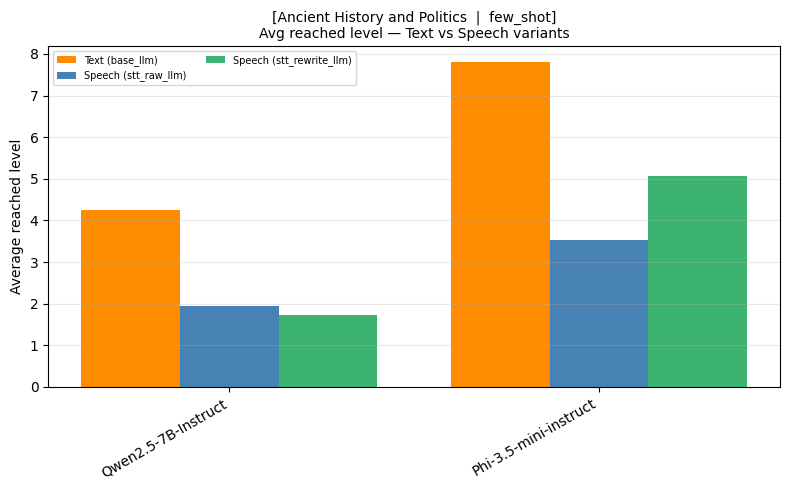

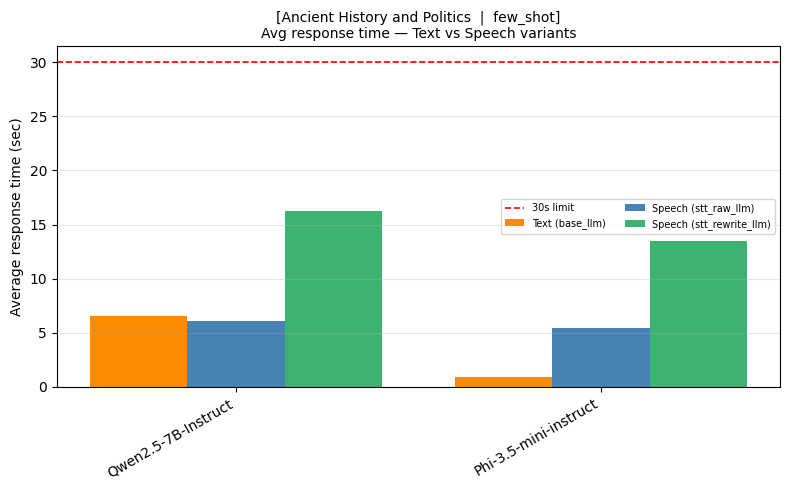

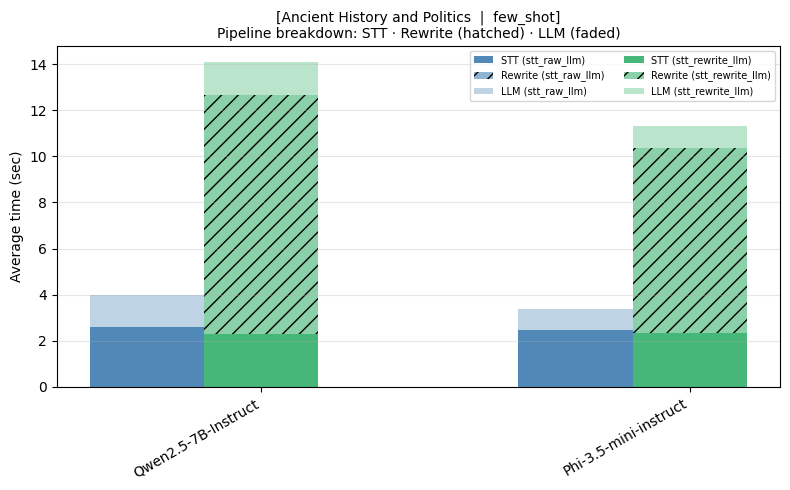


  [Ancient History and Politics  |  zero_shot]


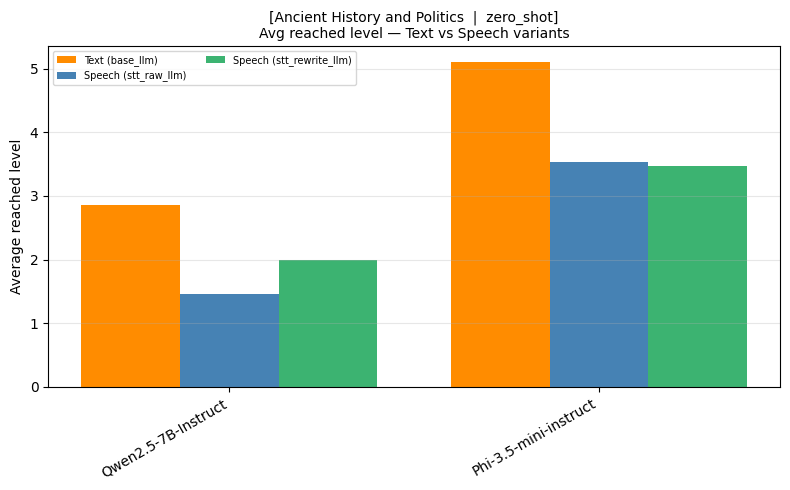

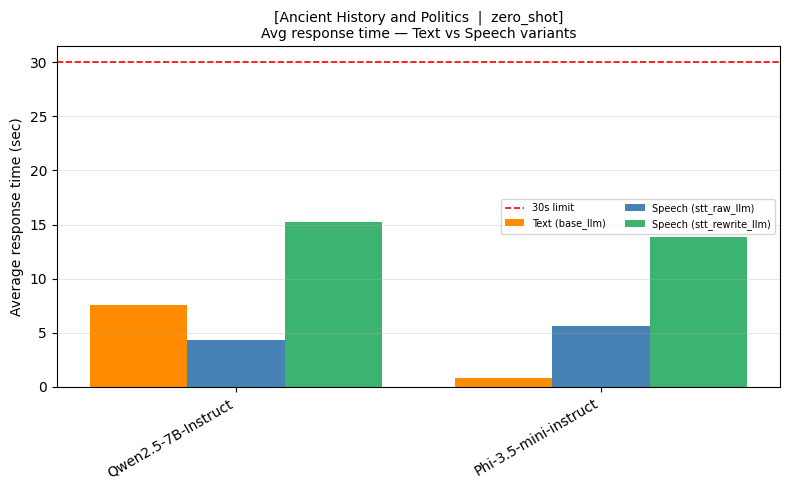

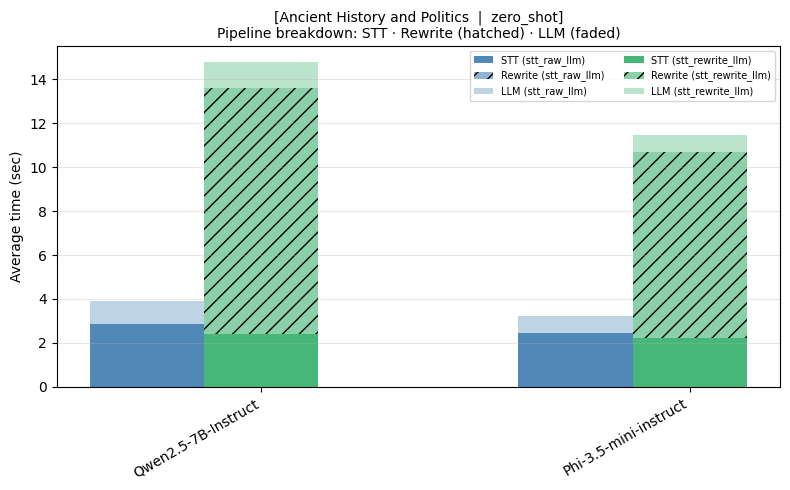


  [News  |  few_shot]


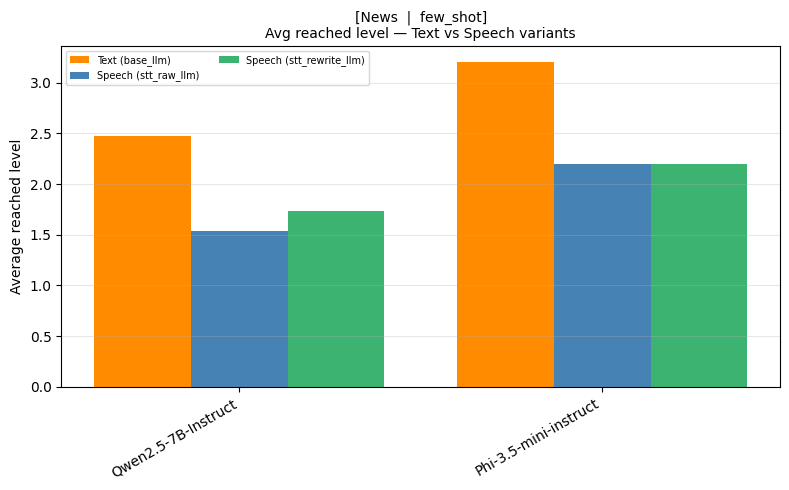

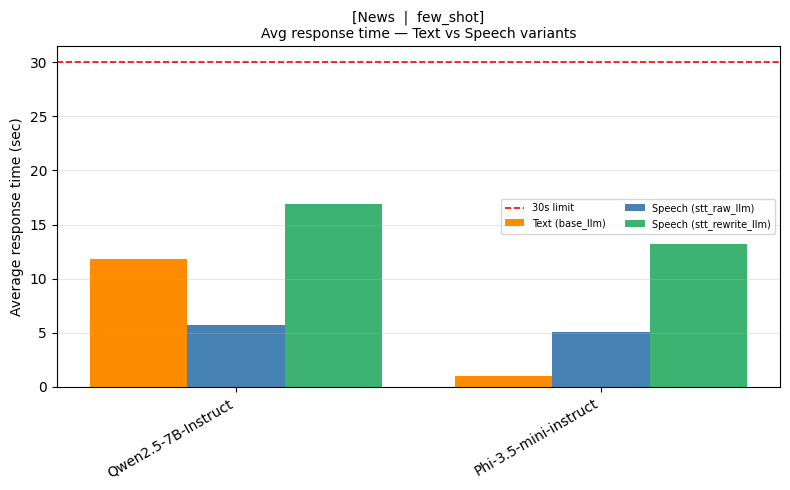

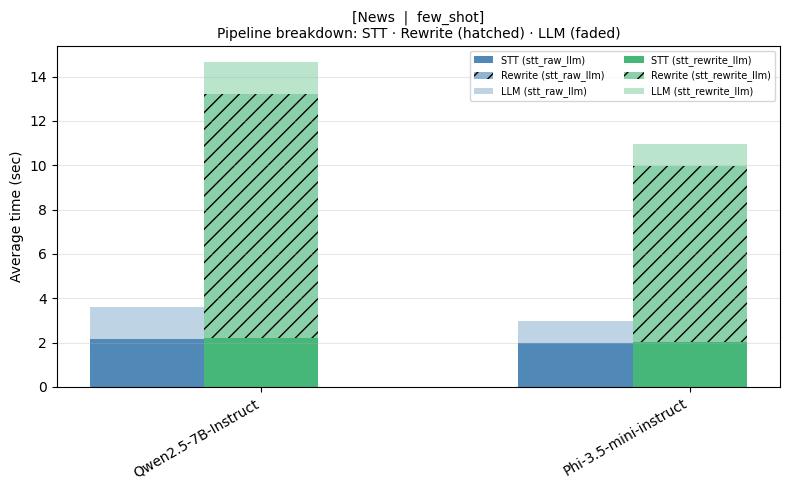


  [News  |  zero_shot]


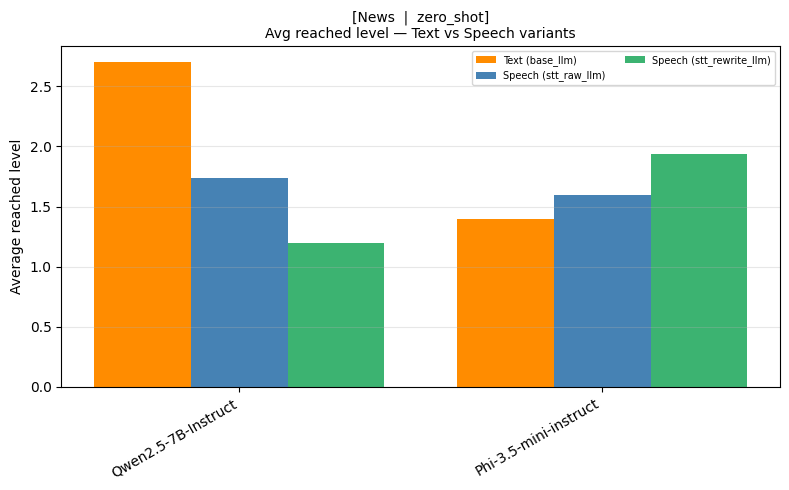

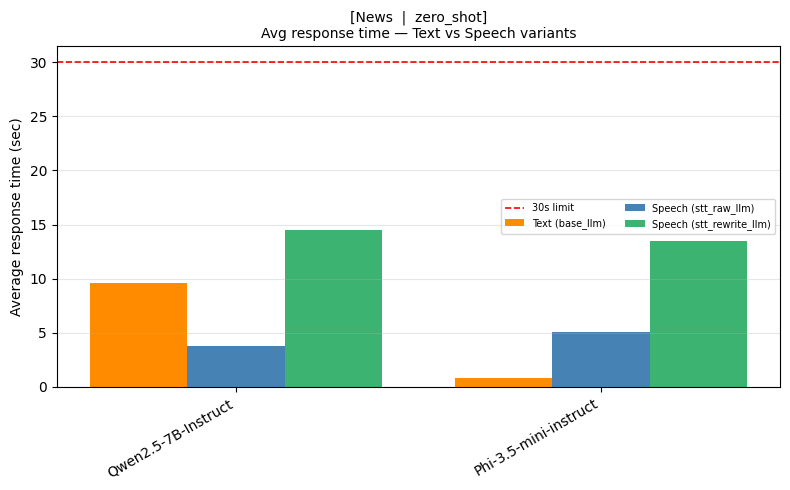

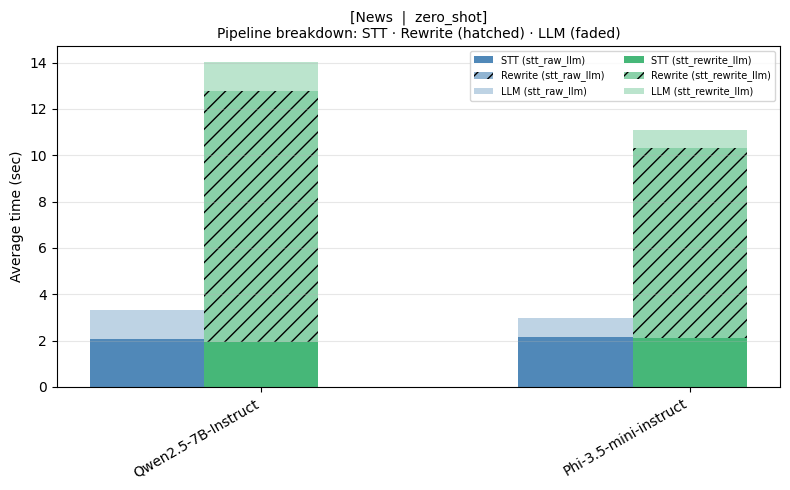

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Paths
# ============================================================

LOG_ROOT        = Path("/content/gdrive/MyDrive/NLP/PoliMillionaire/logs")
SPEECH_LOG_ROOT = Path("/content/gdrive/MyDrive/NLP/PoliMillionaire/logs_speech")

TEXT_CSV   = LOG_ROOT        / "aggregate_by_prompt_category.csv"
SPEECH_CSV = SPEECH_LOG_ROOT / "speech_aggregate_by_variant_prompt_category.csv"

TIME_LIMIT_SEC = 30

# ============================================================
# Load
# ============================================================

text_df   = pd.read_csv(TEXT_CSV)
speech_df = pd.read_csv(SPEECH_CSV)

# ============================================================
# Common models
# ============================================================

common_models = set(text_df["model_id"]) & set(speech_df["model_id"])

text_filtered   = text_df[text_df["model_id"].isin(common_models)].copy()
speech_filtered = speech_df[speech_df["model_id"].isin(common_models)].copy()

# ============================================================
# Build common (category, strategy) combos
# ============================================================

text_combos   = set(zip(text_filtered["competition_name"],
                        text_filtered["benchmark_prompt_strategy"]))
speech_combos = set(zip(speech_filtered["competition_name"],
                        speech_filtered["benchmark_prompt_strategy"]))
common_combos = sorted(text_combos & speech_combos)

print(f"Common models          : {len(common_models)}")
print(f"Common (cat, strategy) : {len(common_combos)}")
for c in common_combos:
    print(f"  {c}")

# ============================================================
# Helpers
# ============================================================

speech_variants = sorted(speech_filtered["speech_variant_name"].dropna().unique())
variant_colors  = ["steelblue", "mediumseagreen", "mediumpurple", "tomato"]
all_model_ids   = sorted(common_models)
all_labels      = [m.split("/")[-1] for m in all_model_ids]
n_models        = len(all_model_ids)
x               = list(range(n_models))
n_bars          = 1 + len(speech_variants)
width           = 0.8 / n_bars
offsets         = [-(n_bars - 1) / 2 * width + k * width for k in range(n_bars)]

print(f"Speech variants: {speech_variants}")


def get_values(agg_df, col):
    idx = agg_df.set_index("model_id")
    return [idx.loc[m, col] if m in idx.index else float("nan")
            for m in all_model_ids]


def finish_ax(ax, title, ylabel, time_limit=None):
    ax.set_xticks(x)
    ax.set_xticklabels(all_labels, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    if time_limit:
        ax.axhline(time_limit, linestyle="--", color="red",
                   linewidth=1.2, label=f"{time_limit}s limit")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def agg_text(df, category, strategy):
    return (
        df[(df["competition_name"]          == category) &
           (df["benchmark_prompt_strategy"] == strategy)]
        .groupby("model_id")
        .agg(
            avg_reached_level    =("avg_reached_level",     "mean"),
            avg_response_time_sec=("avg_response_time_sec", "mean"),
        )
        .reset_index()
    )


def agg_speech(df, category, strategy, variant):
    return (
        df[(df["competition_name"]          == category)  &
           (df["benchmark_prompt_strategy"] == strategy)  &
           (df["speech_variant_name"]       == variant)]
        .groupby("model_id")
        .agg(
            avg_reached_level    =("avg_reached_level",     "mean"),
            avg_response_time_sec=("avg_response_time_sec", "mean"),
            avg_stt_time_sec     =("avg_stt_time_sec",      "mean"),
            avg_rewrite_time_sec =("avg_rewrite_time_sec",  "mean"),
            avg_llm_time_sec     =("avg_llm_time_sec",      "mean"),
        )
        .reset_index()
    )

# ============================================================
# Plot — one set of 3 charts per (category × strategy) combo
# ============================================================

for category, strategy in common_combos:

    text_agg     = agg_text(text_filtered, category, strategy)
    variant_aggs = {
        v: agg_speech(speech_filtered, category, strategy, v)
        for v in speech_variants
    }

    # Skip if no data on either side for this combo
    if text_agg.empty and all(df.empty for df in variant_aggs.values()):
        continue

    tag = f"[{category}  |  {strategy}]"
    print(f"\n{'='*60}\n  {tag}\n{'='*60}")

    # --------------------------------------------------
    # Chart 1 — Avg reached level
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(8, n_models * 2), 5))

    ax.bar([i + offsets[0] for i in x],
           get_values(text_agg, "avg_reached_level"),
           width, label="Text (base_llm)", color="darkorange")

    for k, (variant, color) in enumerate(zip(speech_variants, variant_colors), start=1):
        ax.bar([i + offsets[k] for i in x],
               get_values(variant_aggs[variant], "avg_reached_level"),
               width, label=f"Speech ({variant})", color=color)

    finish_ax(ax,
              f"{tag}\nAvg reached level — Text vs Speech variants",
              "Average reached level")

    # --------------------------------------------------
    # Chart 2 — Avg response time
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(8, n_models * 2), 5))

    ax.bar([i + offsets[0] for i in x],
           get_values(text_agg, "avg_response_time_sec"),
           width, label="Text (base_llm)", color="darkorange")

    for k, (variant, color) in enumerate(zip(speech_variants, variant_colors), start=1):
        ax.bar([i + offsets[k] for i in x],
               get_values(variant_aggs[variant], "avg_response_time_sec"),
               width, label=f"Speech ({variant})", color=color)

    finish_ax(ax,
              f"{tag}\nAvg response time — Text vs Speech variants",
              "Average response time (sec)",
              time_limit=TIME_LIMIT_SEC)

    # --------------------------------------------------
    # Chart 3 — Speech pipeline breakdown
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=(max(8, n_models * 2), 5))

    for k, (variant, color) in enumerate(zip(speech_variants, variant_colors)):
        agg          = variant_aggs[variant]
        stt_vals     = get_values(agg, "avg_stt_time_sec")
        rewrite_vals = get_values(agg, "avg_rewrite_time_sec")
        llm_vals     = get_values(agg, "avg_llm_time_sec")
        bottom_rw    = [s + r for s, r in zip(stt_vals, rewrite_vals)]
        xs           = [i + offsets[k] for i in x]

        ax.bar(xs, stt_vals,     width,
               label=f"STT ({variant})",     color=color, alpha=0.95)
        ax.bar(xs, rewrite_vals, width, bottom=stt_vals,
               label=f"Rewrite ({variant})", color=color, alpha=0.60, hatch="//")
        ax.bar(xs, llm_vals,     width, bottom=bottom_rw,
               label=f"LLM ({variant})",     color=color, alpha=0.35)

    finish_ax(ax,
              f"{tag}\nPipeline breakdown: STT · Rewrite (hatched) · LLM (faded)",
              "Average time (sec)")